# AllLife Bank - Credit Card Customer Segmentation


## Pattern Discovery with Unsupervised Learning


Project Submitted by : DEEPA C A

# Business Context

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help



# Objective

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.



# Data Description
The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

# Data Dictionary
Sl_No: Primary key of the records

Customer Key: Customer identification number

Average Credit Limit: Average credit limit of each customer for all credit cards

Total credit cards: Total number of credit cards possessed by the customer

Total visits bank: Total number of visits that the customer made (yearly) personally to the bank

Total visits online: Total number of visits or online logins made by the customer (yearly)

Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

# Exploratory Data Analysis (EDA)

**Load the dataset From Drive**

In [ ]:
import pandas as pd
# Mounting the G Drive
from google.colab import drive
drive.mount("/content/drive")

# Loading the Datafeed placed in the Google drive path
df = pd.read_excel('/content/drive/MyDrive/Credit Card Customer Data.xlsx')

Mounted at /content/drive


**Display First 5 rows of dataset**

In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


**Display Last 5 rows of dataset**

In [ ]:
df.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


**Shape of Dataset**

In [ ]:
df.shape

(660, 7)

There are 660 rows and 7 columns

**Find null or missing values**

In [ ]:
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


There are no missing data.


**Find Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values

**Find non- unique values of Customer Key**

In [ ]:
df[df.duplicated(subset=['Customer Key'], keep=False)]

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
4,5,47437,100000,6,0,12,3
48,49,37252,6000,4,0,2,8
104,105,97935,17000,2,1,2,10
332,333,47437,17000,7,3,1,0
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
411,412,50706,44000,4,5,0,2
432,433,37252,59000,6,2,1,2
541,542,50706,60000,7,5,2,2
632,633,97935,187000,7,1,7,0


From the above, we can see the data is different for the unique key.The 'Customer Key' is a unique ID given to each customer in the database. The duplicate values might correspond to customer profile changes, and as such, there is no need to delete these records as these are actual occurrences at some point in the time.

**Statistical Inference of Numerical Data**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


Memory Usage looks ok and all are numerical values.

**Inference of Numerical and Categorical Data**

### Inference from Statistical Data:

*   **Data Types**: All columns are of integer type (`int64`), which is appropriate for numerical analysis. This ensures there are no issues with mixed data types or incorrect interpretations.
*   **Missing Values**: As previously observed, there are no missing values in the dataset, indicating a clean dataset ready for analysis.
*   **Identifier Columns**: `Sl_No` and `Customer Key` are unique identifiers for each record and customer, respectively. These columns are not suitable for direct use in clustering algorithms as they do not represent behavioral or financial attributes.
*   **Average Credit Limit (`Avg_Credit_Limit`)**:
    *   The credit limits range from 3,000 to 200,000.
    *   The mean (34,574) is significantly higher than the median (18,000), and the 75th percentile is 48,000. This indicates a right-skewed distribution, meaning a larger number of customers have lower credit limits, while a smaller group has considerably higher limits.
*   **Total Credit Cards (`Total_Credit_Cards`)**:
    *   Customers possess between 1 and 10 credit cards, with an average of approximately 4.7 cards.
    *   The median is 5, suggesting a fairly even distribution around the mean.
*   **Total Visits Bank (`Total_visits_bank`)**:
    *   Bank visits range from 0 to 5 times a year.
    *   The average is around 2.4 visits, with the median also at 2. Most customers visit the bank a few times annually.
*   **Total Visits Online (`Total_visits_online`)**:
    *   Online visits range from 0 to 15 times a year.
    *   The mean is about 2.6 visits, with the median at 2. This shows that while most customers engage online a few times, some customers are very active online, making up to 15 visits.
*   **Total Calls Made (`Total_calls_made`)**:
    *   Customers make between 0 and 10 calls annually.
    *   The average is approximately 3.58 calls, with the median at 3. This indicates a moderate level of customer interaction through calls.

# Univariate Analysis


Descriptive statistics for Avg_Credit_Limit:
count       660.000000
mean      34574.242424
std       37625.487804
min        3000.000000
25%       10000.000000
50%       18000.000000
75%       48000.000000
max      200000.000000
Name: Avg_Credit_Limit, dtype: float64


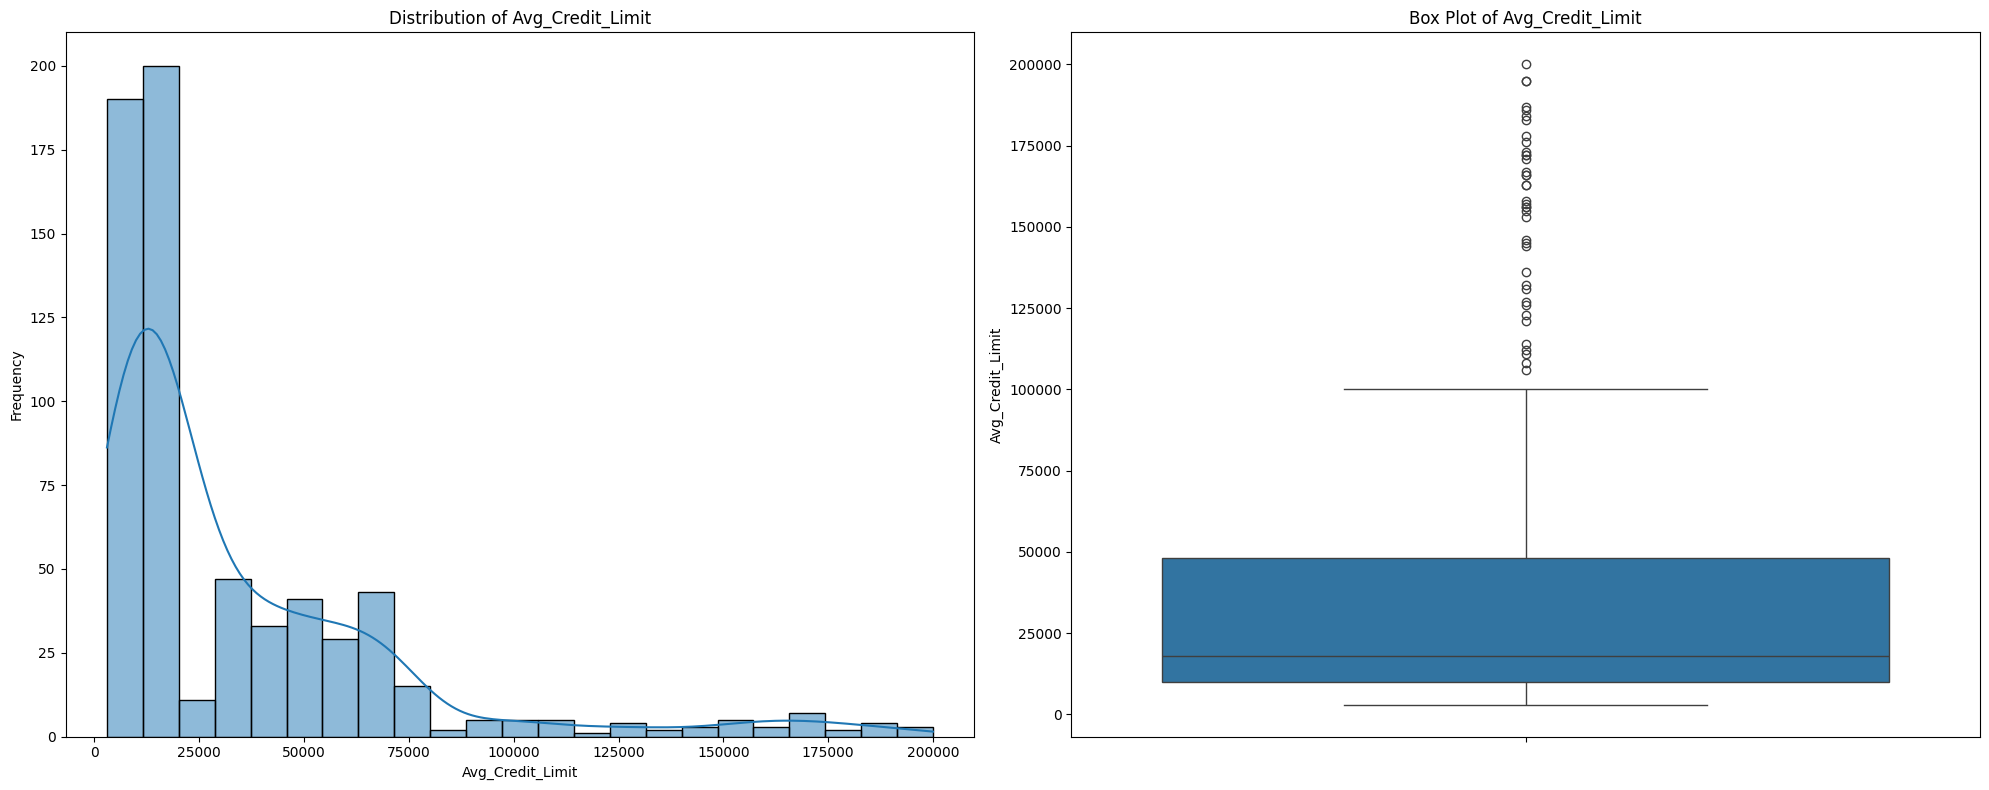

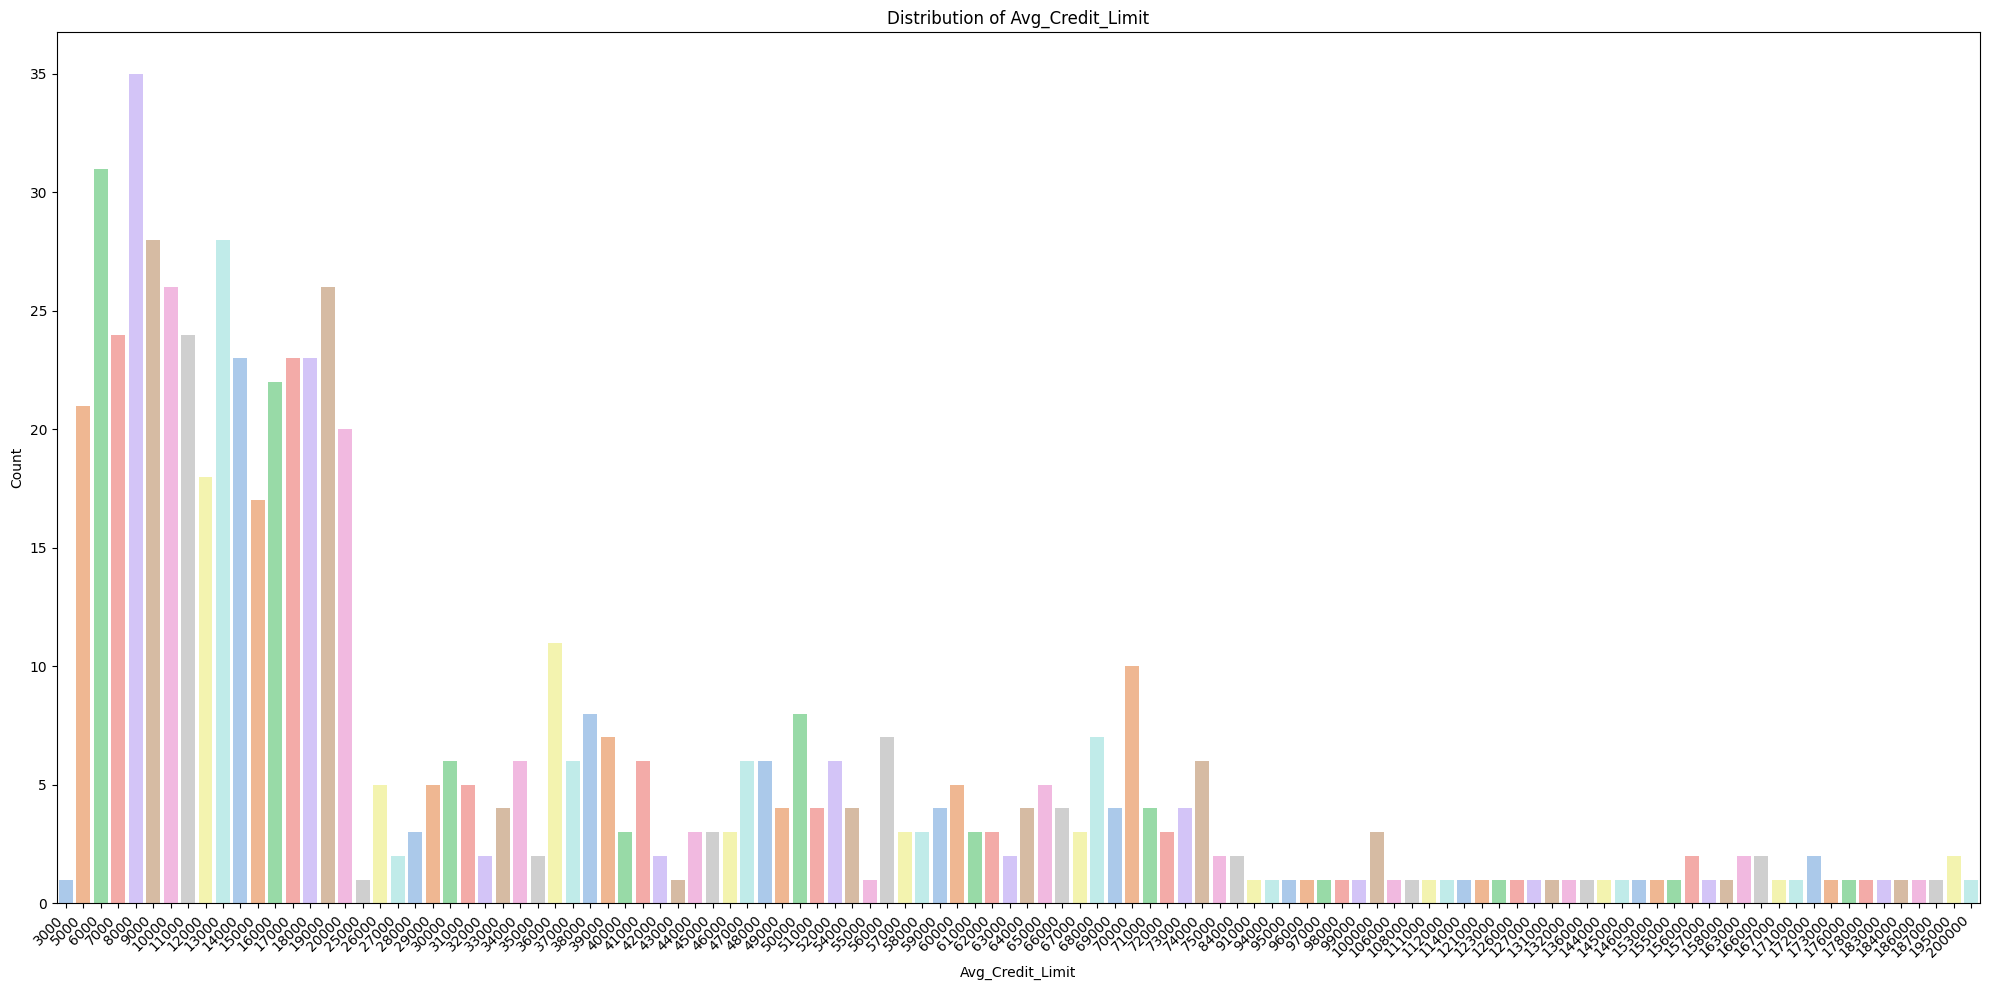


Descriptive statistics for Total_Credit_Cards:
count    660.000000
mean       4.706061
std        2.167835
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       10.000000
Name: Total_Credit_Cards, dtype: float64


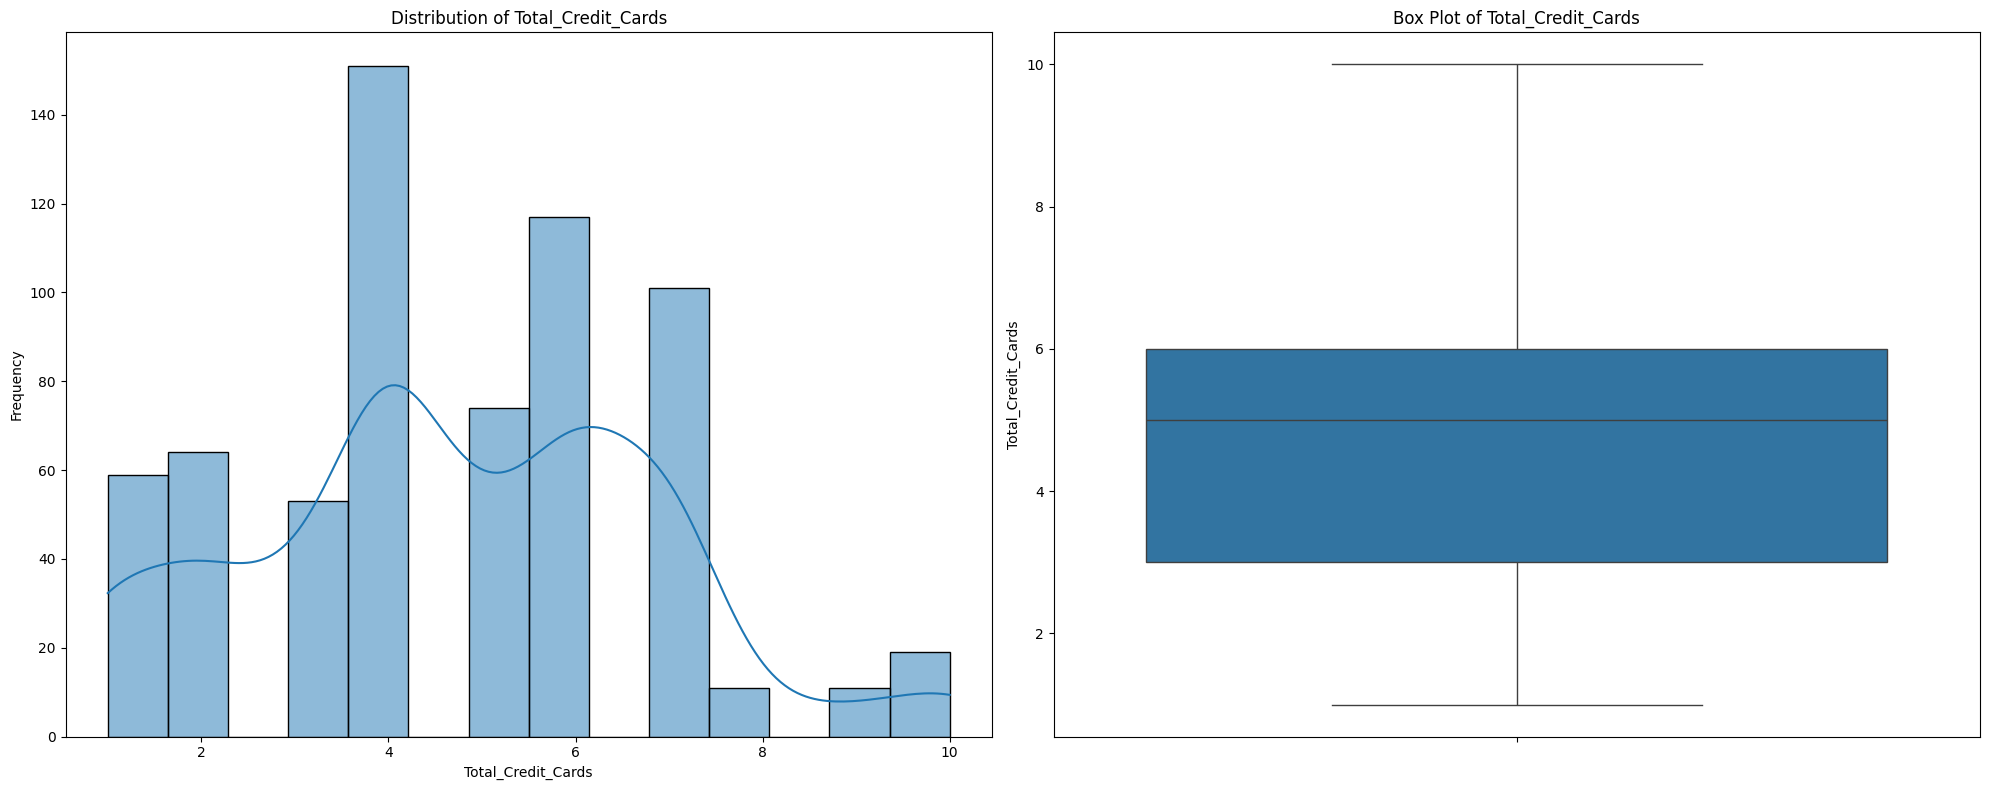

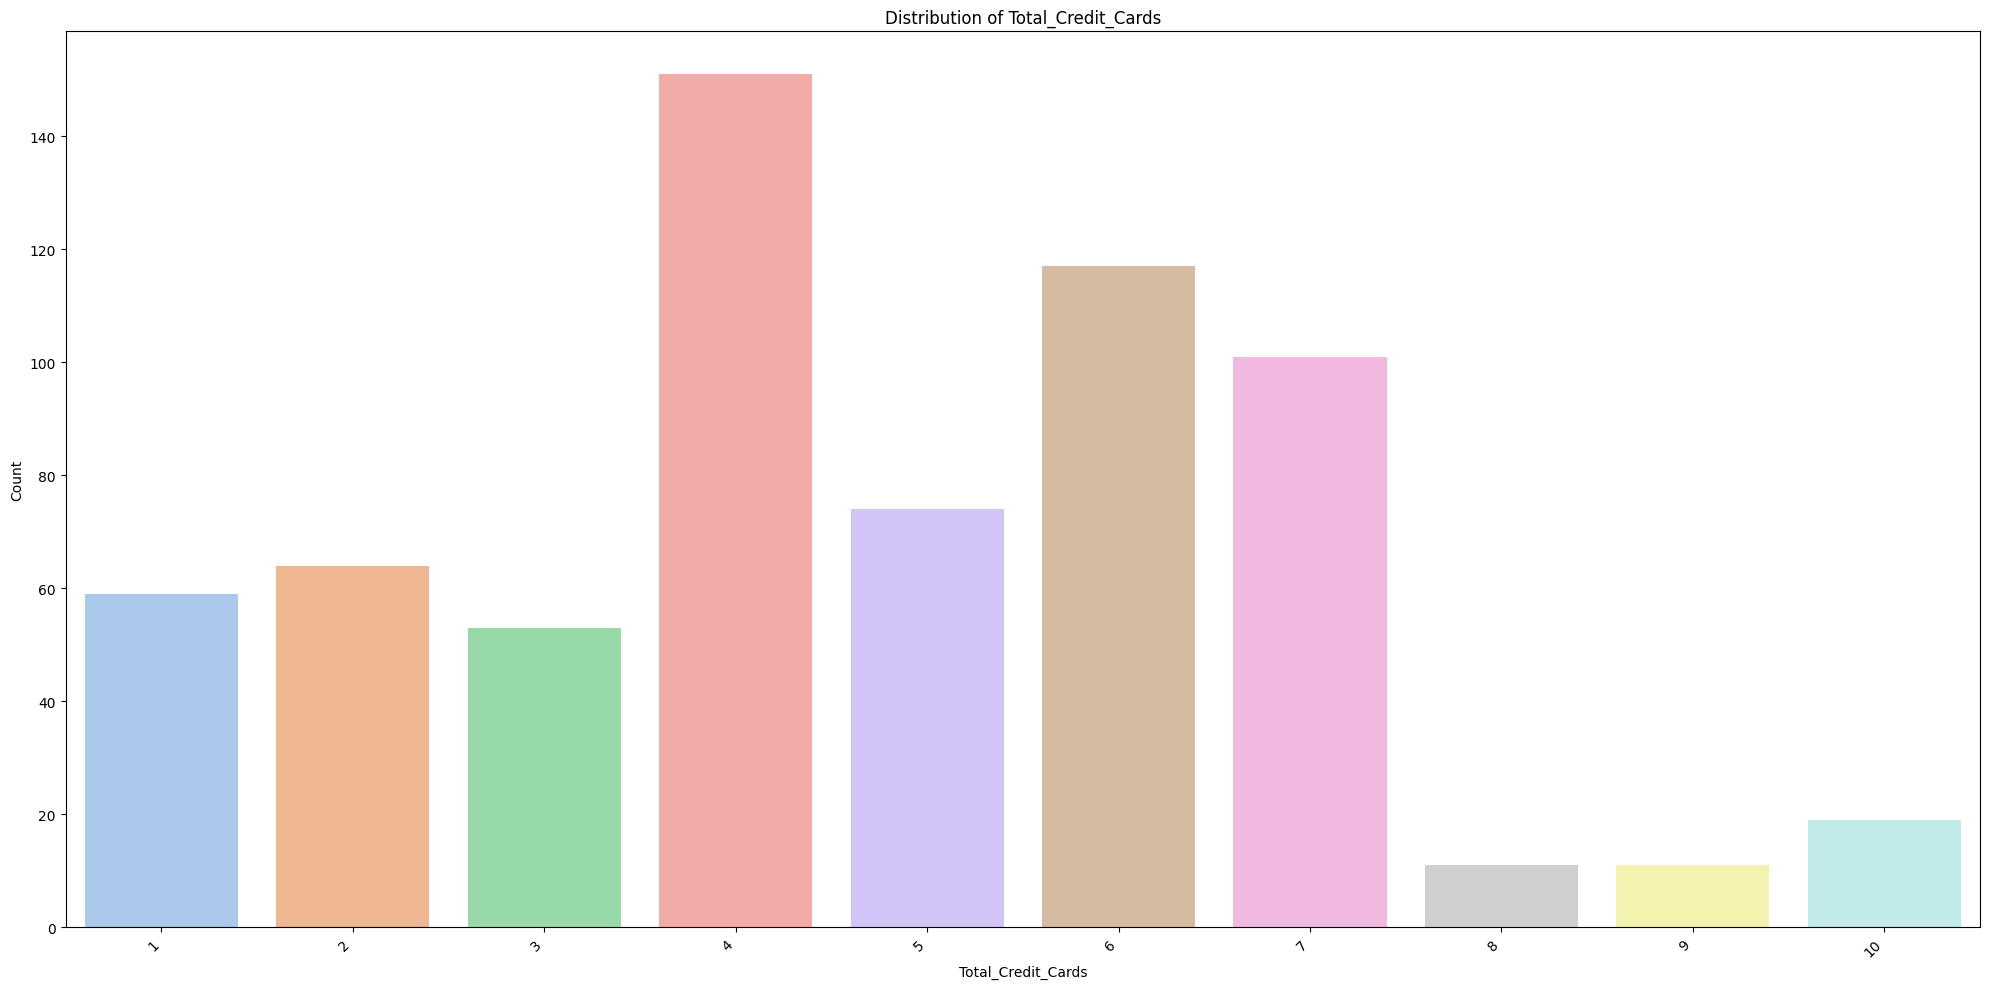


Descriptive statistics for Total_visits_bank:
count    660.000000
mean       2.403030
std        1.631813
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        5.000000
Name: Total_visits_bank, dtype: float64


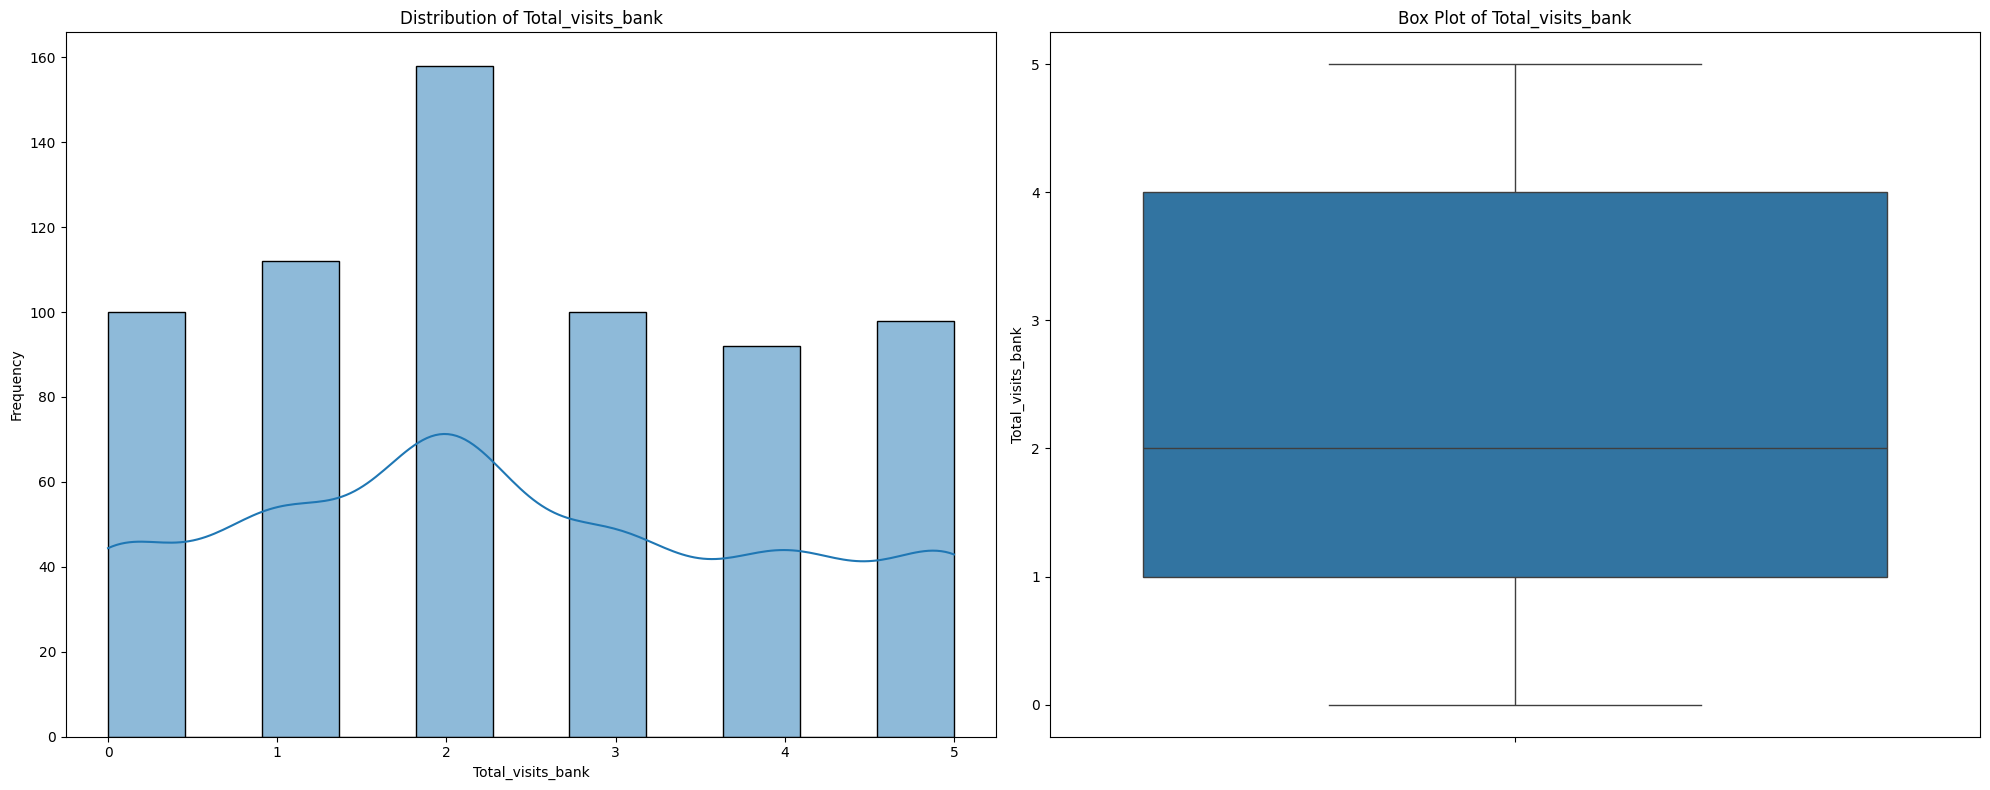

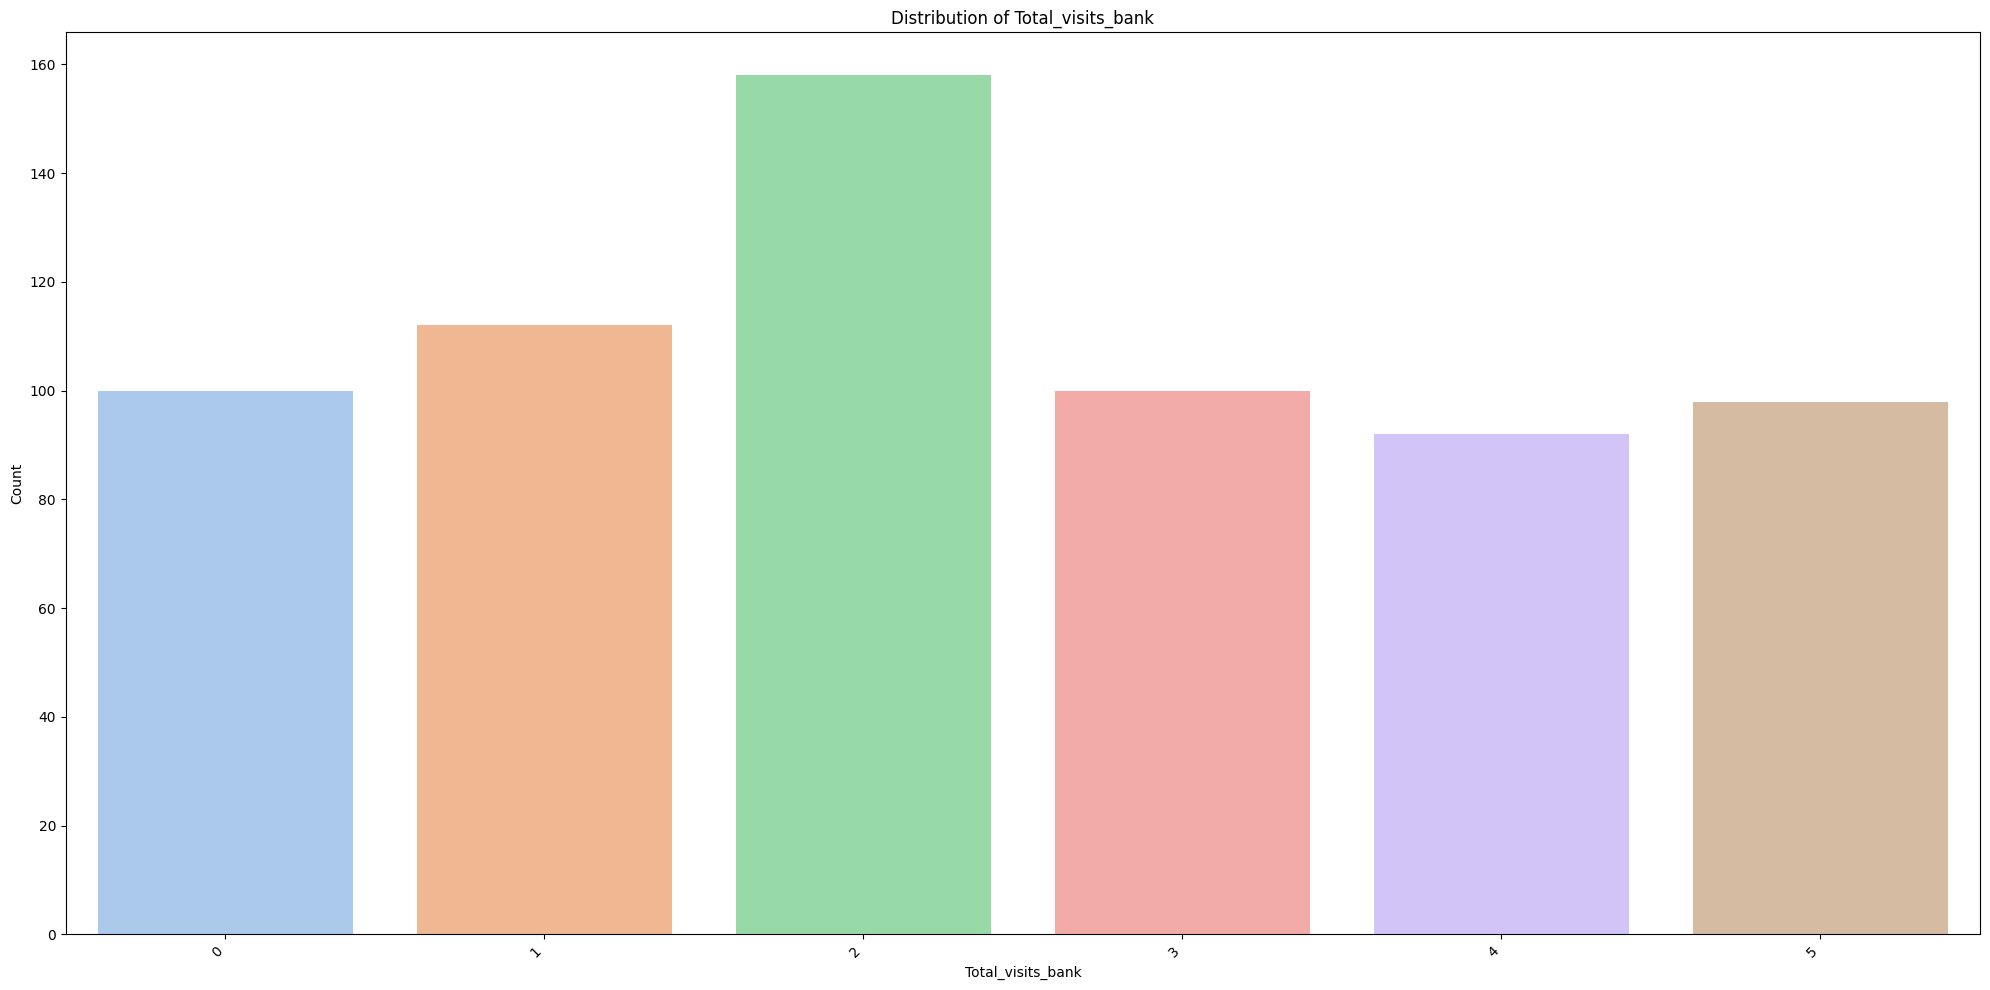


Descriptive statistics for Total_visits_online:
count    660.000000
mean       2.606061
std        2.935724
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: Total_visits_online, dtype: float64


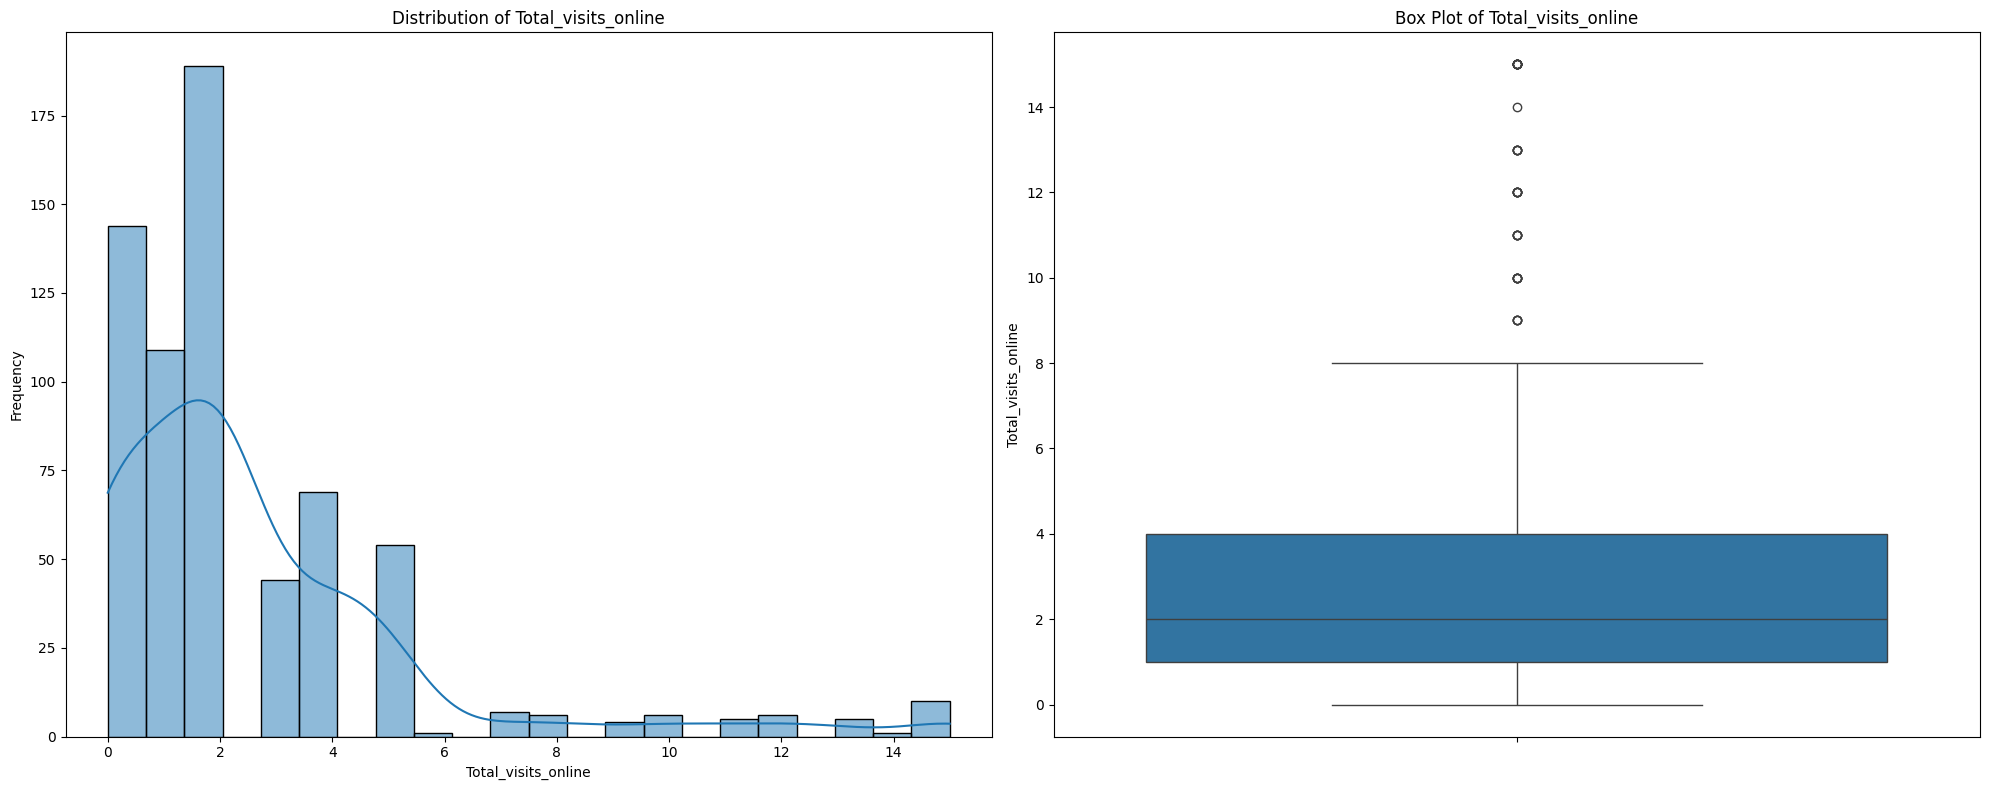

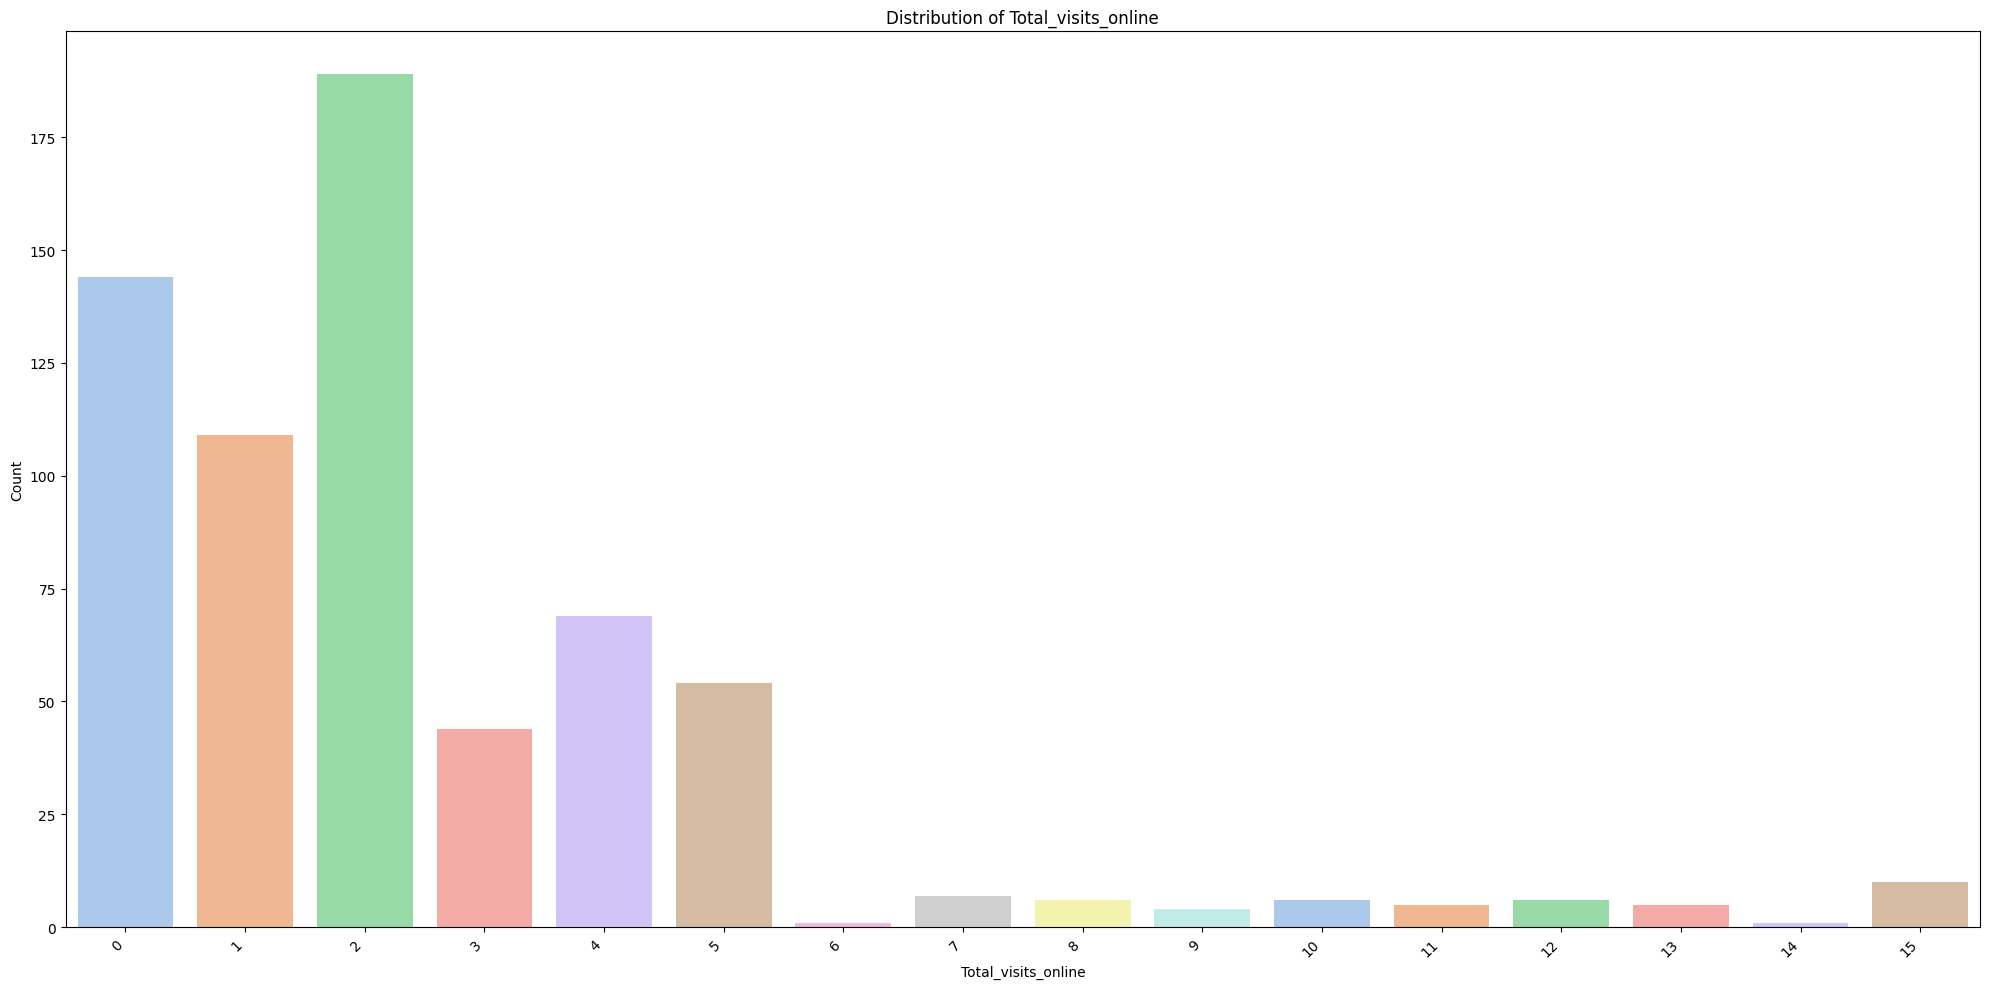


Descriptive statistics for Total_calls_made:
count    660.000000
mean       3.583333
std        2.865317
min        0.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       10.000000
Name: Total_calls_made, dtype: float64


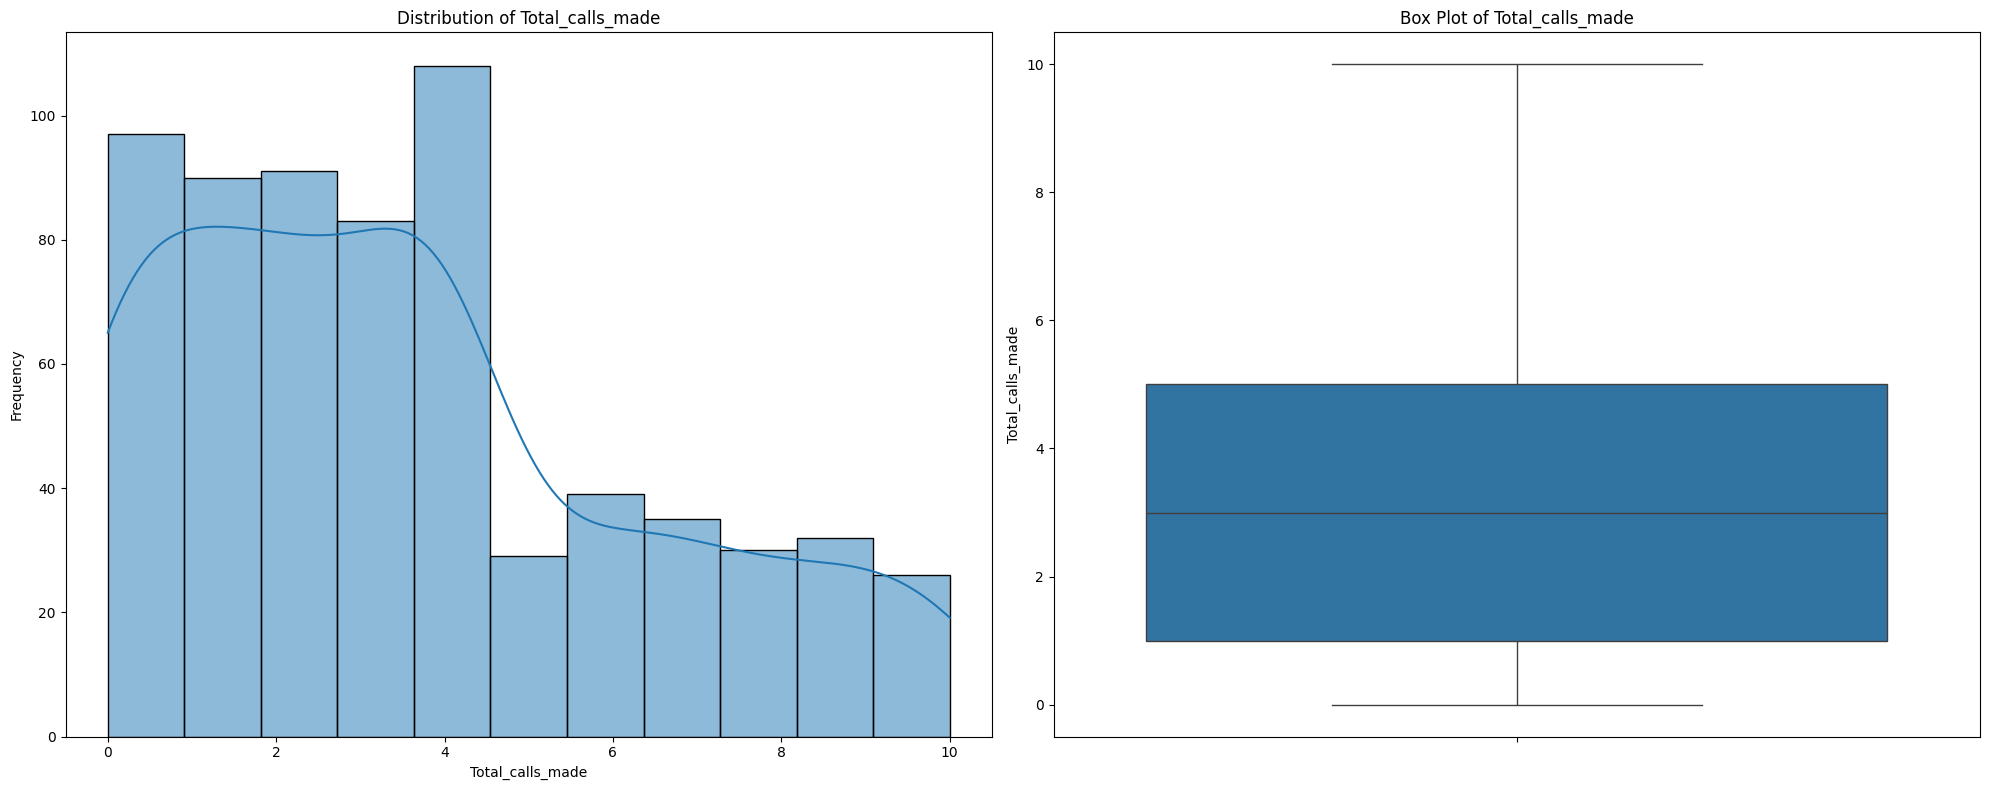

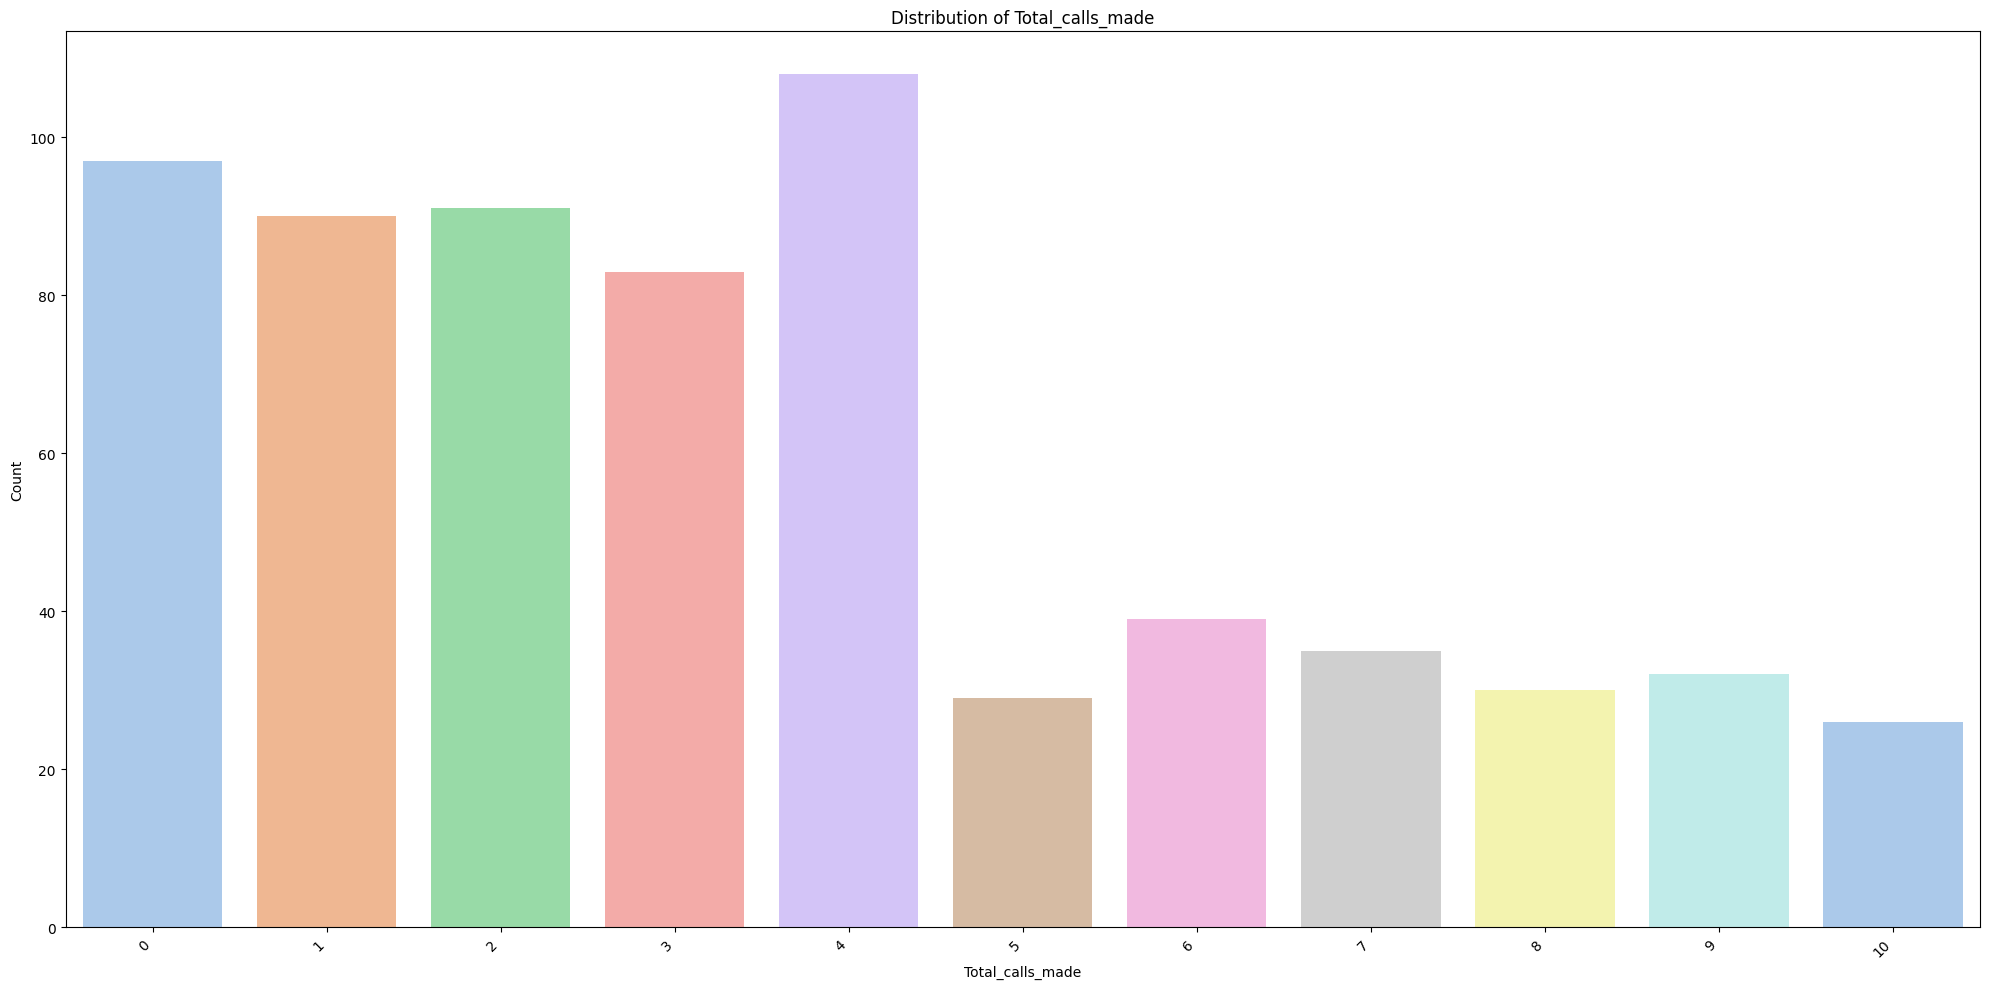

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

numerical_cols = ['Avg_Credit_Limit',  'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

def numerical_univariate_analysis(df, column):
    print(f"\nDescriptive statistics for {column}:")
    print(df[column].describe())

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

     # Create a bar plot
    plt.figure(figsize=(20, 10))
    sns.countplot(data=df, x=column, hue=column, palette='pastel', legend=False)
    plt.title(f'Distribution of {column
                                 }')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for col in numerical_cols:
    numerical_univariate_analysis(df, col)


### Inferences from Univariate Analysis:

1.  **Average Credit Limit (`Avg_Credit_Limit`)**:
    *   **Distribution**: The histogram and descriptive statistics show a right-skewed distribution. A large number of customers have low to moderate credit limits (below 50,000), while a smaller proportion have very high credit limits (up to 200,000).
    *   **Central Tendency & Spread**: The mean (34,574) is considerably higher than the median (18,000), confirming the right-skewness. The standard deviation (37,625) is also large, indicating significant variability in credit limits.
    *   **Outliers**: The box plot clearly shows many outliers on the higher end, indicating a segment of customers with exceptionally high credit limits compared to the majority.
    *   **Count Plot**: For this continuous variable, the count plot reinforces the right-skewness, showing fewer observations as the credit limit increases.

2.  **Total Credit Cards (`Total_Credit_Cards`)**:
    *   **Distribution**: The distribution appears somewhat balanced, with a slight peak around 3-7 credit cards. Most customers hold between 1 and 7 cards.
    *   **Central Tendency & Spread**: The mean (4.7) and median (5) are very close, suggesting a relatively symmetric distribution for the number of credit cards. The range is from 1 to 10.
    *   **Outliers**: The box plot shows no significant outliers, indicating that the number of credit cards held by customers is mostly within a typical range.
    *   **Count Plot**: This plot effectively visualizes the frequency of each number of credit cards, showing common patterns like many customers having 3, 5, or 6 cards.

3.  **Total Visits Bank (`Total_visits_bank`)**:
    *   **Distribution**: The distribution is discrete and shows that a significant portion of customers visit the bank 0, 1, or 2 times. There's a gradual decrease in frequency as the number of visits increases.
    *   **Central Tendency & Spread**: The mean is 2.4 visits, with the median at 2. The maximum visits are 5, indicating that very few customers visit the bank frequently.
    *   **Outliers**: The box plot shows no significant outliers, suggesting that the observed visit counts are within expected bounds for the dataset.
    *   **Count Plot**: This is highly effective, showing clear bars for each visit count, with 1 visit being the most frequent, followed by 0 and 2 visits.

4.  **Total Visits Online (`Total_visits_online`)**:
    *   **Distribution**: Similar to bank visits, online visits are discrete. There's a tendency for customers to have 0, 1, or 2 online visits, but there's a long tail extending up to 15 visits.
    *   **Central Tendency & Spread**: The mean is 2.6 visits, with the median at 2. The maximum is 15, which is quite high compared to the average.
    *   **Outliers**: The box plot indicates several outliers on the higher end, suggesting some customers are highly active online.
    *   **Count Plot**: This plot highlights that while many customers have low online activity, a smaller group engages very frequently online, which aligns with the outliers seen in the box plot.

5.  **Total Calls Made (`Total_calls_made`)**:
    *   **Distribution**: The distribution for calls made is also discrete, showing peaks at lower call counts (0-2 calls), and then a decreasing frequency as the number of calls increases.
    *   **Central Tendency & Spread**: The mean is 3.58 calls, with the median at 3. The maximum calls are 10.
    *   **Outliers**: The box plot indicates no significant outliers, suggesting a consistent pattern of customer calls within the observed range.
    *   **Count Plot**: This plot provides a clear view of the frequency of customers making different numbers of calls, with 0, 1, and 2 calls being very common.

# Bivariate Analysis

**Bivariate Analysis  - Correlation Heatmap Analysis for Numerical Columns**

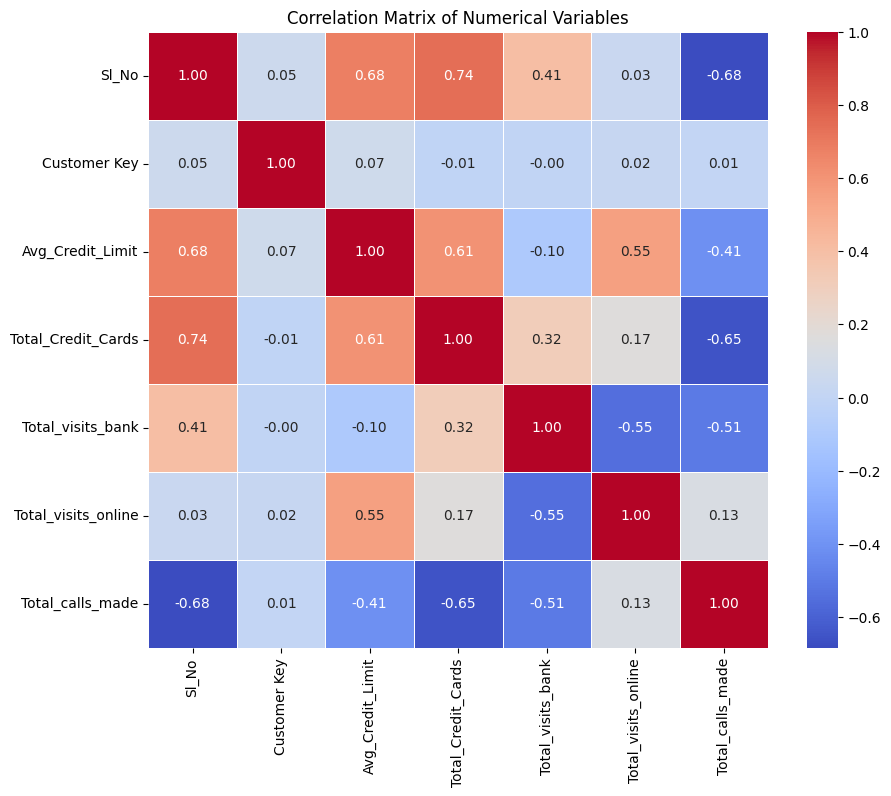

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [ ]:
correlation_matrix

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Sl_No,1.000000,0.052886,0.677962,0.739329,0.406438,0.033916,-0.684125
Customer Key,0.052886,1.000000,0.068604,-0.010281,-0.000560,0.022506,0.005968
Avg_Credit_Limit,0.677962,0.068604,1.000000,0.608860,-0.100312,0.551385,-0.414352
Total_Credit_Cards,0.739329,-0.010281,0.608860,1.000000,0.315796,0.167758,-0.651251
Total_visits_bank,0.406438,-0.000560,-0.100312,0.315796,1.000000,-0.551861,-0.506016
Total_visits_online,0.033916,0.022506,0.551385,0.167758,-0.551861,1.000000,0.127299
Total_calls_made,-0.684125,0.005968,-0.414352,-0.651251,-0.506016,0.127299,1.000000


### Inferences from Correlation Matrix:

1.  **Strong Positive Correlation: `Avg_Credit_Limit` and `Total_Credit_Cards` (0.61)**
    *   This indicates a moderately strong positive relationship: as a customer's average credit limit increases, they tend to possess more credit cards, and vice versa. This is an expected and logical relationship, as banks often offer higher credit limits to customers with multiple cards or a good credit history.

2.  **Moderate Positive Correlation: `Avg_Credit_Limit` and `Total_visits_online` (0.55)**
    *   Customers with higher average credit limits tend to have more online visits. This could imply that customers with higher credit limits are more digitally active in managing their accounts or exploring banking services online.

3.  **Strong Negative Correlation: `Total_calls_made` and `Total_Credit_Cards` (-0.65)**
    *   There is a strong inverse relationship between the number of calls made and the total credit cards a customer has. Customers with more credit cards tend to make fewer calls to the bank. This might suggest that customers with more cards are more self-sufficient in managing their finances, or they might be more experienced and require less assistance.

4.  **Moderate Negative Correlation: `Total_visits_bank` and `Total_visits_online` (-0.55)**
    *   This shows a moderate inverse relationship: customers who visit the bank more frequently tend to visit online less, and vice versa. This suggests a behavioral segmentation where customers prefer either physical banking or digital banking channels.

5.  **Moderate Negative Correlation: `Total_calls_made` and `Avg_Credit_Limit` (-0.41)**
    *   Customers with higher average credit limits tend to make fewer calls to the bank. This aligns with the idea that financially more stable or experienced customers might require less direct assistance.

6.  **Weak/Negligible Correlations**:
    *   `Customer Key` and `Sl_No` have very low or negligible correlations with other variables, as expected, since they are identifiers and not behavioral or financial metrics.
    *   Most other correlations are weak (close to 0), indicating that those pairs of variables do not have a strong linear relationship. For example, `Total_visits_bank` and `Total_Credit_Cards` have a weak positive correlation (0.32), suggesting that having more cards doesn't strongly dictate bank visits.

### Pairplot for Bivariate Analysis

A pairplot visualize pairwise relationships between variables, as well as the distribution of each variable. We will use the `numerical_cols` defined earlier for this.

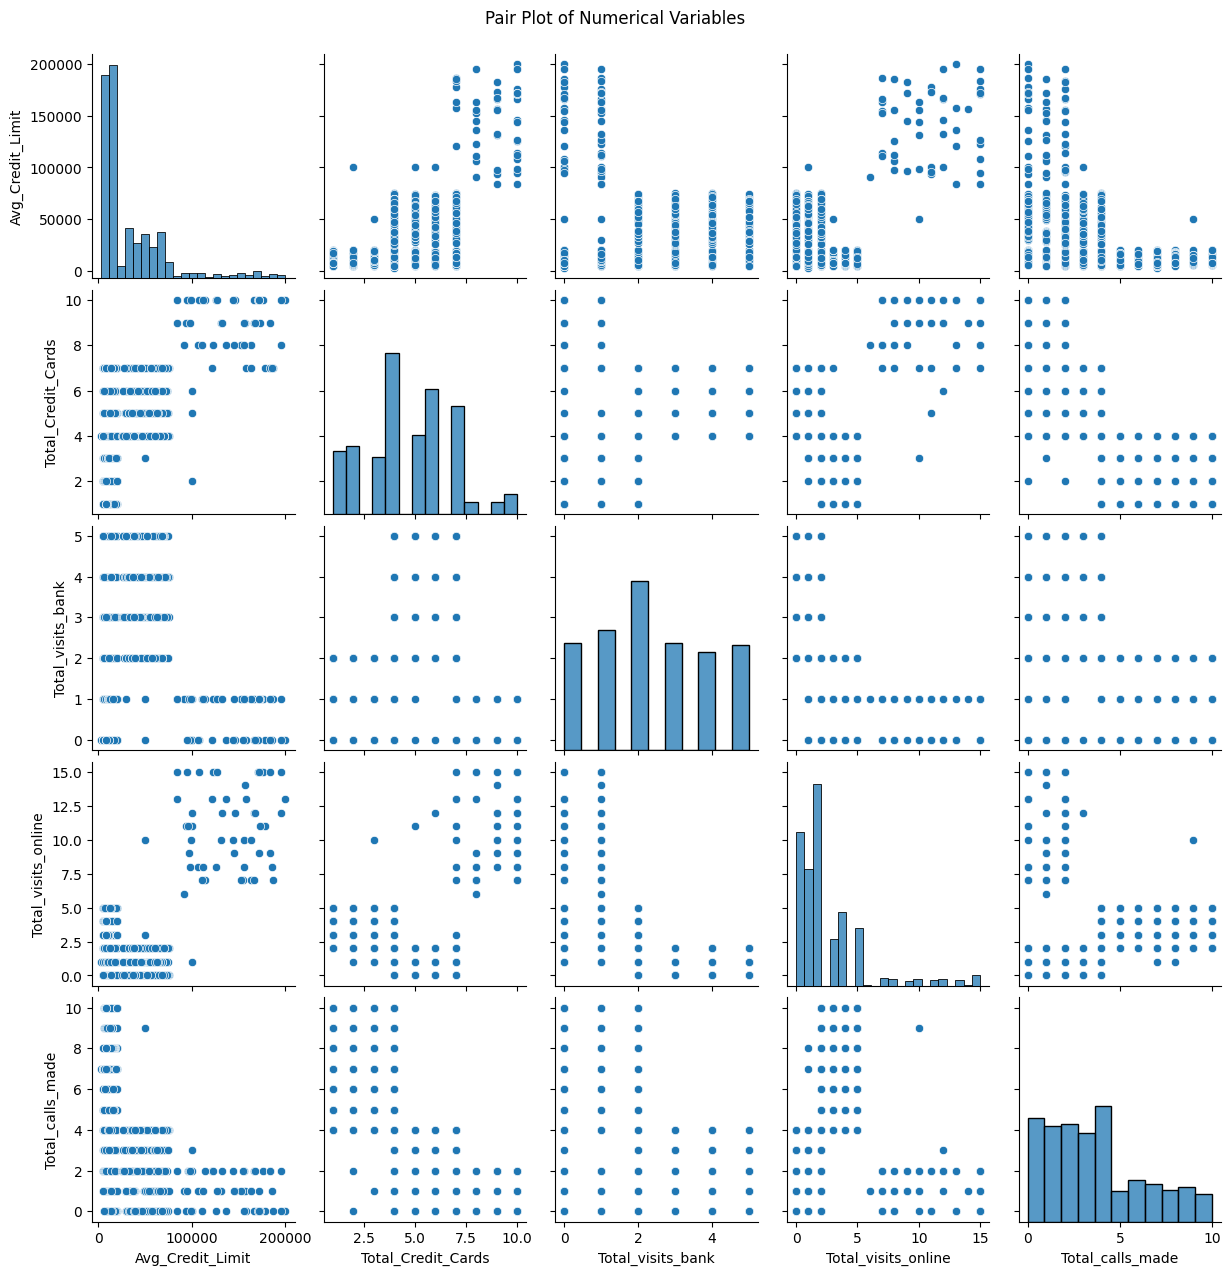

In [ ]:
numerical_cols = ['Avg_Credit_Limit',  'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
sns.pairplot(df[numerical_cols])
plt.suptitle('Pair Plot of Numerical Variables', y=1.02) # Adjust suptitle to not overlap
plt.show()

### Inferences from Pair Plot:

1.  **Diagonal Plots (Histograms/KDEs)**:
    *   The diagonal plots show the univariate distribution of each numerical variable. These confirm observations from the earlier univariate analysis:
        *   `Avg_Credit_Limit` is right-skewed, indicating more customers with lower credit limits.
        *   `Total_Credit_Cards` shows a somewhat normal distribution, centered around 4-6 cards.
        *   `Total_visits_bank`, `Total_visits_online`, and `Total_calls_made` are discrete and show distributions concentrated at lower values, with some customers having higher activity (especially online visits).

2.  **Off-Diagonal Scatter Plots (Bivariate Relationships)**:
    *   **`Avg_Credit_Limit` vs. `Total_Credit_Cards`**: The scatter plot shows a clear positive linear relationship, reaffirming that customers with higher credit limits tend to have more credit cards. The points are not perfectly aligned, indicating some variability but a general trend.
    *   **`Avg_Credit_Limit` vs. `Total_visits_online`**: A positive, but less pronounced, linear relationship is visible. Customers with higher credit limits tend to visit online more, but there's a wider spread of data points.
    *   **`Total_calls_made` vs. `Total_Credit_Cards`**: This plot vividly displays the strong negative correlation. As the number of credit cards increases, the number of calls made generally decreases. This implies that customers with more cards might be more experienced and require less assistance.
    *   **`Total_visits_bank` vs. `Total_visits_online`**: A clear negative correlation is observed. As bank visits increase, online visits tend to decrease, and vice versa. This visually confirms the inverse relationship, suggesting customers tend to prefer one channel over the other.
    *   **`Total_calls_made` vs. `Avg_Credit_Limit`**: The negative correlation is evident, albeit with more scatter. Higher credit limits are associated with fewer calls.

3.  **General Observations**:
    *   The pairplot helps visualize not just the presence, but also the strength and linearity of the correlations identified in the correlation matrix.
    *   Many relationships, while statistically correlated, show a fair amount of spread, indicating that while trends exist, they are not perfectly predictive.
    *   The plots for discrete variables (e.g., `Total_Credit_Cards`, `Total_visits_bank`) show distinct clusters or lines of points rather than continuous distributions, as expected.

### Joint Plot for Bivariate Analysis

Let's create a joint plot for `Avg_Credit_Limit` and `Total_Credit_Cards` to see their joint distribution and individual distributions. We can use a scatter plot for the main bivariate relationship and histograms for the marginal distributions.

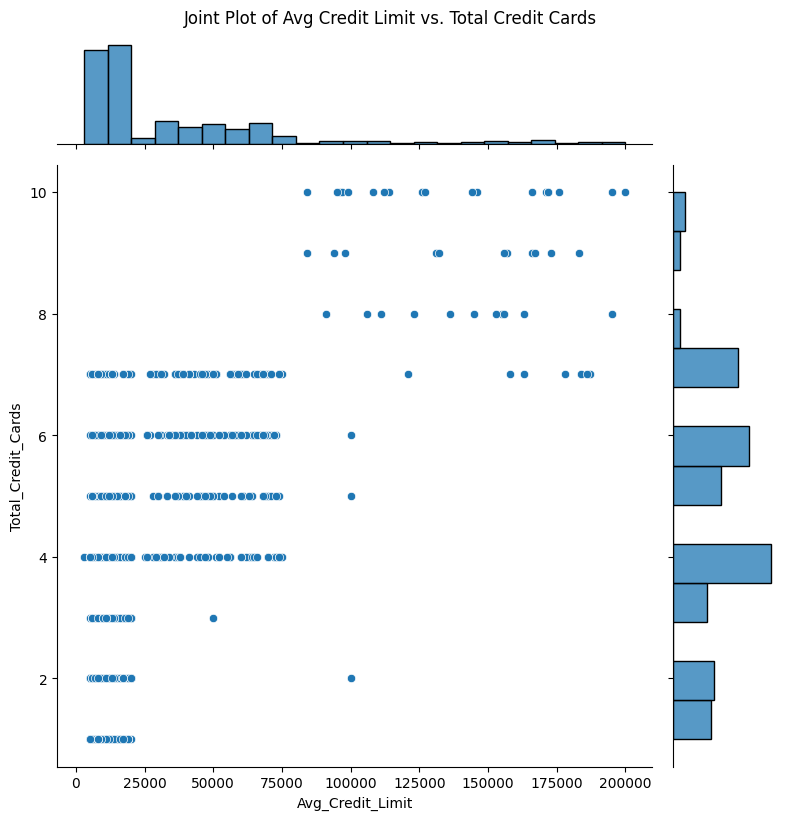

In [ ]:
sns.jointplot(x='Avg_Credit_Limit', y='Total_Credit_Cards', data=df, kind='scatter', height=8)
plt.suptitle('Joint Plot of Avg Credit Limit vs. Total Credit Cards', y=1.02) # Adjust suptitle
plt.show()

We can also use a different `kind` for the joint plot, like `kde` for kernel density estimates or `hex` for hexbin plots, especially useful for visualizing density in large datasets or where overplotting is an issue. Let's try a hexbin plot for `Total_visits_bank` and `Total_visits_online`.

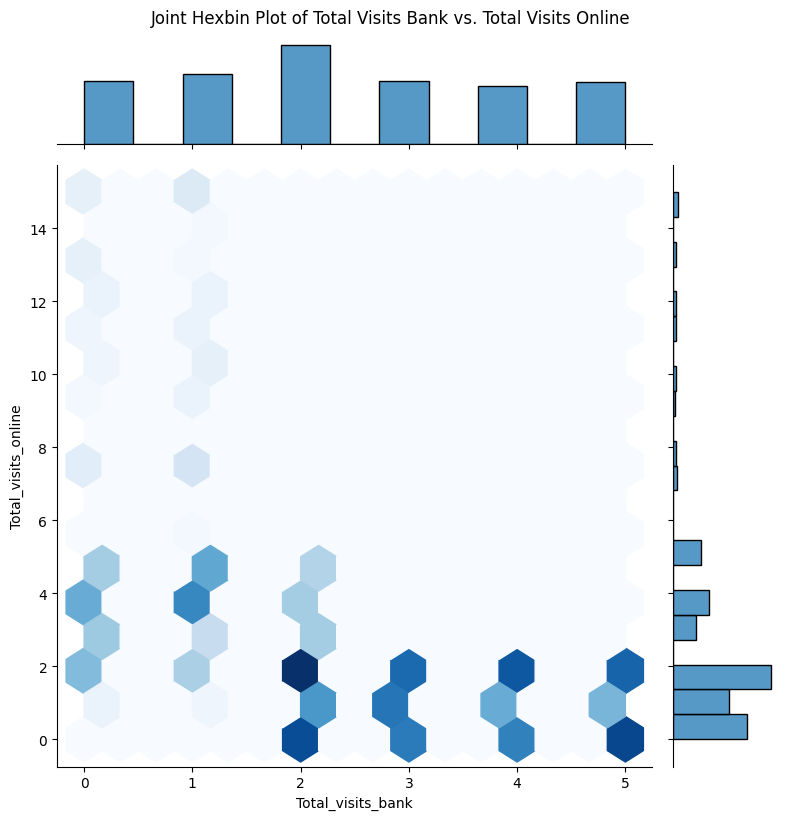

In [ ]:
sns.jointplot(x='Total_visits_bank', y='Total_visits_online', data=df, kind='hex', height=8, cmap='Blues')
plt.suptitle('Joint Hexbin Plot of Total Visits Bank vs. Total Visits Online', y=1.02)
plt.show()

### Inferences from Joint Plots:

1.  **Joint Plot: `Avg_Credit_Limit` vs. `Total_Credit_Cards` (`kind='scatter'`)**:
    *   **Bivariate Relationship**: The scatter plot in the center clearly shows a positive linear trend. As the `Avg_Credit_Limit` increases, the `Total_Credit_Cards` generally also increase. This reinforces our earlier observation from the correlation matrix and pairplot.
    *   **Marginal Distributions**:
        *   The histogram for `Avg_Credit_Limit` (top margin) confirms its right-skewed distribution, with a high concentration of customers having lower credit limits.
        *   The histogram for `Total_Credit_Cards` (right margin) shows a somewhat symmetric distribution, with peaks around 3-6 cards, indicating that most customers hold a moderate number of credit cards.
    *   **Overall**: This plot effectively visualizes how customers with higher credit limits are associated with possessing more credit cards, and vice versa.

2.  **Joint Plot: `Total_visits_bank` vs. `Total_visits_online` (`kind='hex'`)**:
    *   **Bivariate Relationship**: The hexbin plot in the center shows the density of data points. The hexagonal bins are darker where more data points are concentrated. We can observe a strong inverse relationship:
        *   There's a dense cluster of customers with low `Total_visits_bank` and high `Total_visits_online` (bottom-right).
        *   Conversely, there are dense clusters of customers with high `Total_visits_bank` and low `Total_visits_online` (top-left).
        *   This pattern strongly confirms the negative correlation, suggesting that customers tend to prefer one channel (physical bank or online) over the other for their interactions.
    *   **Marginal Distributions**:
        *   The histograms on the margins show the discrete nature of these variables, with frequencies concentrated at lower visit counts for both `Total_visits_bank` and `Total_visits_online`.
    *   **Overall**: The hexbin plot is particularly useful here to show the density of customers in different interaction patterns, highlighting the clear channel preference.

### Group Plots: Binning Numerical Data for Categorical Visualization

To create 'group plots' from purely numerical data, we can convert a continuous numerical variable into a categorical one by binning. This allows us to observe how relationships between other variables might differ across these newly defined groups.

Let's create a new column, `Credit_Limit_Group`, by categorizing `Avg_Credit_Limit` into 'Low', 'Medium', and 'High' groups.

In [ ]:
df_new = df.copy()

In [ ]:
df_new.shape

(660, 7)

In [ ]:
bins = [df_new['Avg_Credit_Limit'].min(), 30000, 70000, df['Avg_Credit_Limit'].max()]
labels = ['Low_Credit_Limit', 'Medium_Credit_Limit', 'High_Credit_Limit']
df_new['Credit_Limit_Group'] = pd.cut(df_new['Avg_Credit_Limit'], bins=bins, labels=labels, include_lowest=True)

display(df_new.head())

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Credit_Limit_Group
0,1,87073,100000,2,1,1,0,High_Credit_Limit
1,2,38414,50000,3,0,10,9,Medium_Credit_Limit
2,3,17341,50000,7,1,3,4,Medium_Credit_Limit
3,4,40496,30000,5,1,1,4,Low_Credit_Limit
4,5,47437,100000,6,0,12,3,High_Credit_Limit


Now that we have a categorical `Credit_Limit_Group`, we can use it to create a 'group plot'. Let's visualize the relationship between `Total_Credit_Cards` and `Total_calls_made`, colored by this new `Credit_Limit_Group`.

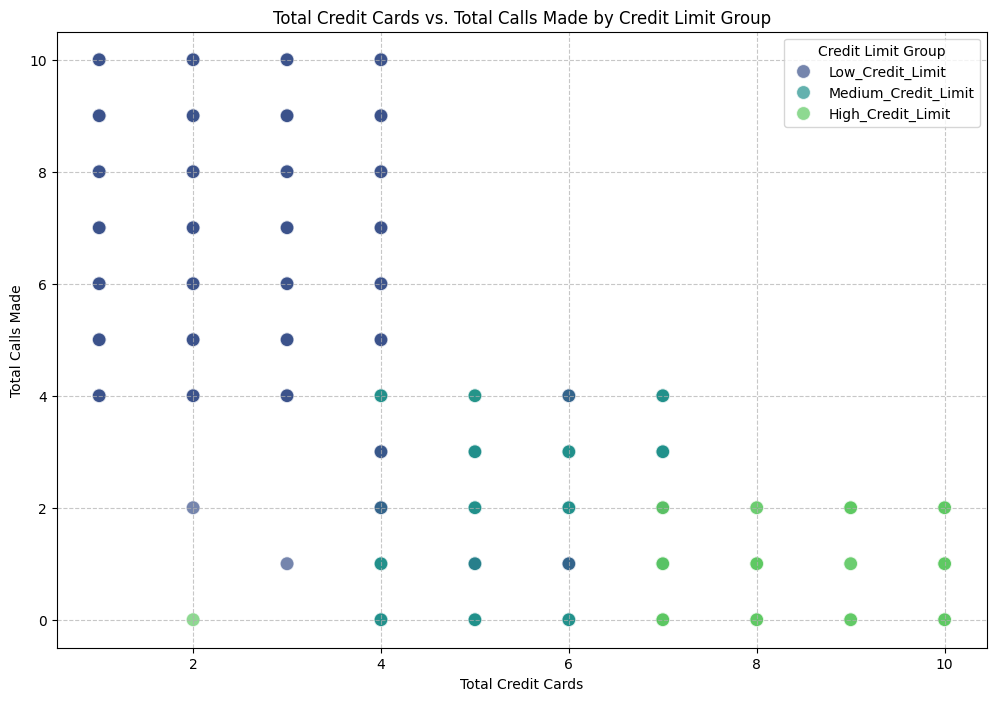

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Total_Credit_Cards', y='Total_calls_made', hue='Credit_Limit_Group', data=df_new, palette='viridis', s=100, alpha=0.7)
plt.title('Total Credit Cards vs. Total Calls Made by Credit Limit Group')
plt.xlabel('Total Credit Cards')
plt.ylabel('Total Calls Made')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Credit Limit Group')
plt.show()

### Inferences from Group Plot (`Total_Credit_Cards` vs. `Total_calls_made` by `Credit_Limit_Group`):

This scatter plot, colored by the `Credit_Limit_Group`, provides a more nuanced understanding of the relationships we observed earlier:

1.  **Inverse Relationship Confirmation**: The overall negative correlation between `Total_Credit_Cards` and `Total_calls_made` is still evident across all groups: generally, as the number of credit cards increases, the number of calls made decreases.

2.  **Distinct Group Behaviors**:
    *   **Low_Credit_Limit Group**: This group (`Low_Credit_Limit`) tends to have fewer credit cards (mostly 1 to 5) and generally makes more calls, especially in the lower range of total credit cards. This suggests that customers with lower credit limits might require more assistance or have more queries, possibly due to less experience or different financial needs.
    *   **Medium_Credit_Limit Group**: This group shows a wider spread in both `Total_Credit_Cards` (from 1 to 8) and `Total_calls_made`. The inverse relationship is also visible, but the points are more dispersed than the other groups.
    *   **High_Credit_Limit Group**: Customers with `High_Credit_Limit` tend to possess a greater number of credit cards (mostly 6 to 10) and, notably, make very few calls (often 0, 1, or 2). This reinforces the idea that customers with higher credit limits and more cards are often more self-sufficient, requiring less direct interaction (calls) with the bank.

3.  **Customer Segmentation Clues**: The plot visually suggests distinct customer segments based on their credit limit and interaction patterns:
    *   **High-value, Low-maintenance**: Customers with high credit limits and many cards are typically digitally savvy or experienced, leading to fewer calls.
    *   **Lower-value, Higher-maintenance**: Customers with low credit limits and fewer cards might require more support.

4.  **Implications for Marketing/Service**: This visualization is crucial for targeted strategies. For instance, customers in the `Low_Credit_Limit` group might benefit from educational resources or more accessible support channels, while the `High_Credit_Limit` group might prefer seamless digital experiences and advanced self-service options.

**Grouped Bar Plot**


In [ ]:
def grouped_barplot(data, feature_x, feature_hue, n=None, perc=False):
    """
    Side-by-side barplot for two categorical variables.
    If perc=True, shows proportions within each feature_x category.
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # order x categories by frequency
    x_order = data[feature_x].value_counts().index
    if n is not None:
        x_order = x_order[:n]

    if not perc:
        plt.figure(figsize=(len(x_order) + 2, 6))
        ax = sns.countplot(
            data=data,
            x=feature_x,
            hue=feature_hue,
            order=x_order,
            palette="Paired",
        )
        plt.xticks(rotation=90, fontsize=12)
        plt.ylabel("Count")

        # add count labels
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            x = p.get_x() + p.get_width() / 2
            ax.annotate(
                int(height),
                (x, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points",
            )
        plt.tight_layout()
        plt.show()
    else:
        # compute proportions within each feature_x
        ctab = pd.crosstab(data[feature_x], data[feature_hue])
        ctab = ctab.loc[x_order]
        ctab_perc = ctab.div(ctab.sum(axis=1), axis=0).reset_index()
        df_melt = ctab_perc.melt(id_vars=feature_x,
                                 var_name=feature_hue,
                                 value_name="perc")

        plt.figure(figsize=(len(x_order) + 2, 6))
        ax = sns.barplot(
            data=df_melt,
            x=feature_x,
            y="perc",
            hue=feature_hue,
            palette="Paired",
        )
        plt.xticks(rotation=90, fontsize=12)
        plt.ylabel("Percentage")

        # add percentage labels
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            x = p.get_x() + p.get_width() / 2
            ax.annotate(
                f"{height*100:.1f}%",
                (x, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points",
            )
        plt.tight_layout()
        plt.show()


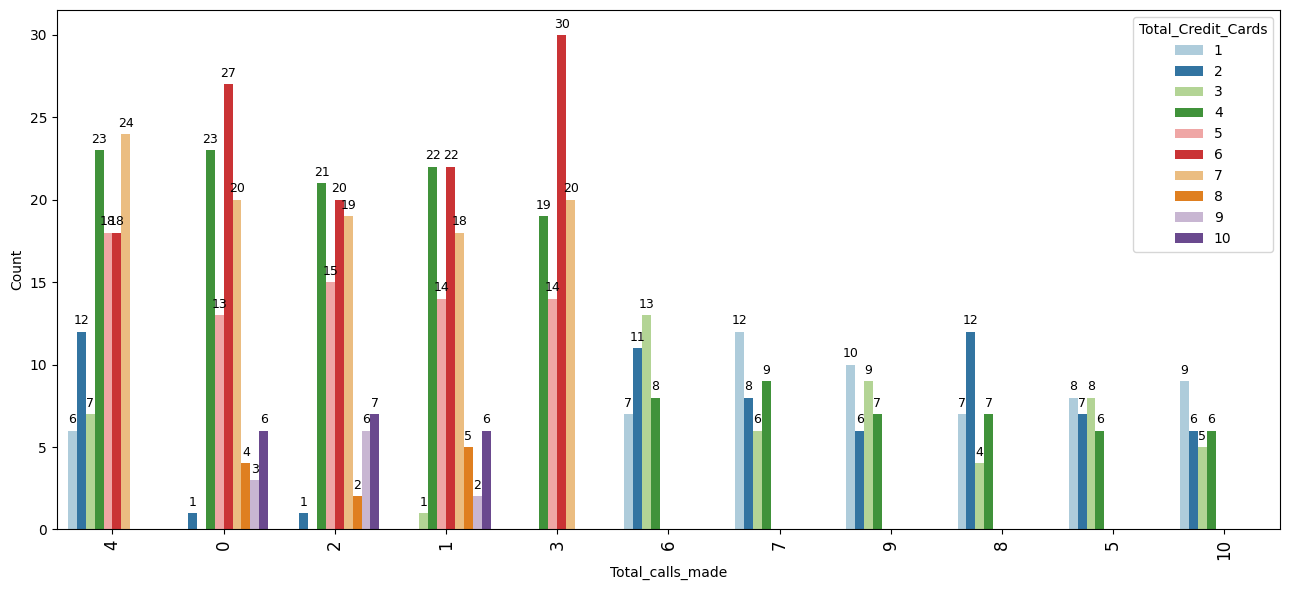

In [ ]:
grouped_barplot(df_new, "Total_calls_made", "Total_Credit_Cards")

We can see , as the total credit cards increase, less calls are made. More calls are made by people with less number of total credit cards.

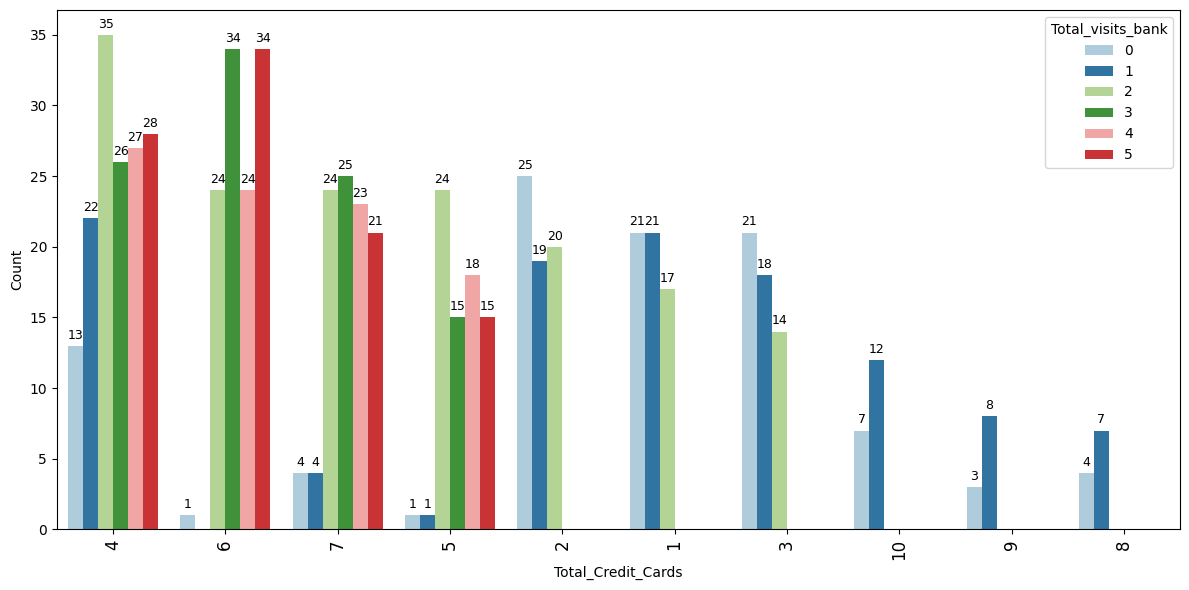

In [ ]:
grouped_barplot(df_new, "Total_Credit_Cards", "Total_visits_bank")

Total Visits to Bank are mostly done by credit card holders with 4 to 7 total credit cards. Lower or higher number of credit card holders visit bank less.

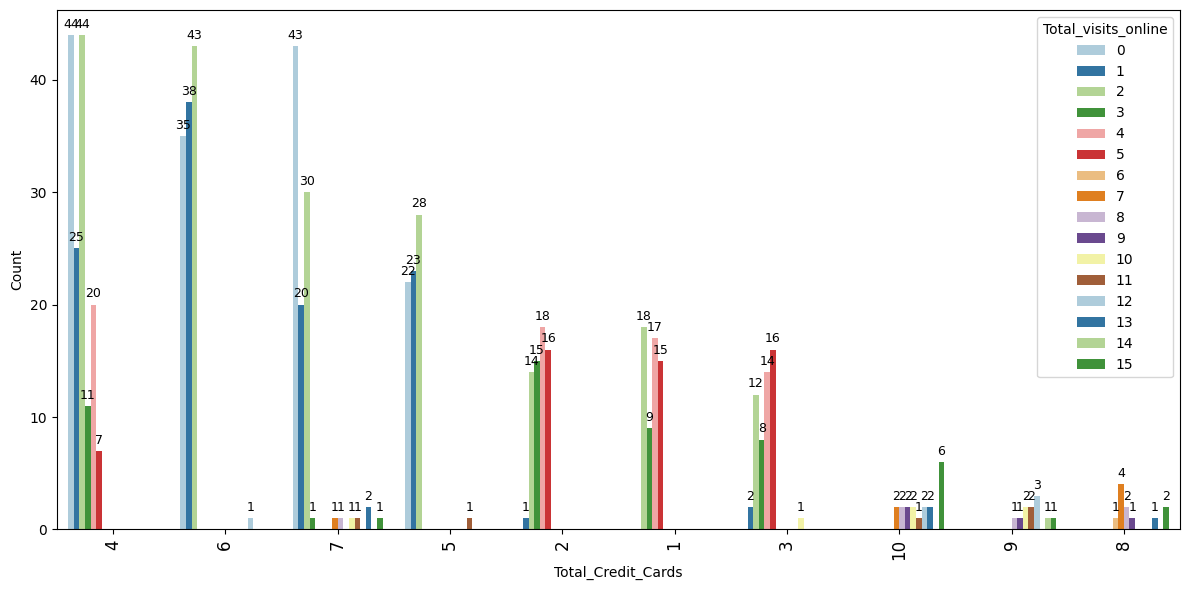

In [ ]:
grouped_barplot(df_new, "Total_Credit_Cards", "Total_visits_online")

### Inferences from Grouped Bar Plots:

1.  **Total Calls Made vs. Total Credit Cards:**
    *   As the total number of credit cards increases, the number of calls made generally decreases. This suggests that customers with more credit cards are likely more self-sufficient or experienced, requiring less direct assistance via calls.
    *   Conversely, customers with fewer credit cards tend to make more calls, possibly indicating a greater need for support or clarification.

2.  **Total Credit Cards vs. Total Visits Bank:**
    *   Customers with a moderate number of credit cards (typically 4 to 7) are more likely to visit the bank physically. This might be a sweet spot where customers have enough products to warrant in-person discussions but are not yet fully digital.
    *   Customers with very few or very many credit cards tend to visit the bank less frequently. This could imply that those with few cards have simpler needs met by other channels, while those with many cards are often higher-value and digitally-inclined, preferring online interactions.

3.  **Total Credit Cards vs. Total Visits Online:**
    *   There is a clear trend indicating that customers with a higher number of credit cards (especially 7 to 10) tend to have a significantly higher number of online visits. This strongly suggests that customers who manage a larger portfolio of credit cards are highly engaged with digital banking platforms.
    *   Conversely, customers with fewer credit cards show lower online activity, which aligns with the observation that they might prefer other channels or have simpler needs.

# Key Meaningful Observations on individual variables and the relationship between variables



# Key Univariate Observations

*   **Avg_Credit_Limit**: Right-skewed distribution with many outliers on the higher end, indicating a segment of customers with exceptionally high credit limits.
*   **Total_Credit_Cards**: Relatively balanced distribution, with most customers holding between 1 and 7 cards, and no significant outliers.
*   **Total_visits_bank**: Discrete distribution concentrated at lower values (0-2 visits), suggesting infrequent physical bank visits for most customers.
*   **Total_visits_online**: Discrete distribution with many customers having low online activity, but also a long tail with outliers showing highly active online users.
*   **Total_calls_made**: Discrete distribution with peaks at lower call counts (0-2 calls), indicating moderate customer interaction through calls, with no significant outliers.

# Key Bivariate Observations

*   **Strong Positive Correlation (0.61)**: `Avg_Credit_Limit` and `Total_Credit_Cards`. Customers with higher credit limits tend to have more credit cards.
*   **Moderate Positive Correlation (0.55)**: `Avg_Credit_Limit` and `Total_visits_online`. Customers with higher credit limits tend to be more active online.
*   **Strong Negative Correlation (-0.65)**: `Total_calls_made` and `Total_Credit_Cards`. Customers with more credit cards tend to make fewer calls.
*   **Moderate Negative Correlation (-0.55)**: `Total_visits_bank` and `Total_visits_online`. Customers tend to prefer either physical banking or digital banking channels, not both equally.
*   **Moderate Negative Correlation (-0.41)**: `Total_calls_made` and `Avg_Credit_Limit`. Higher credit limits are associated with fewer calls.
*   **Group Plot Insights**: By segmenting `Avg_Credit_Limit` into 'Low', 'Medium', and 'High' groups, we observed distinct behaviors:
    *   **Low_Credit_Limit** customers tend to have fewer cards and make more calls.
    *   **High_Credit_Limit** customers tend to have more cards and make very few calls, suggesting self-sufficiency.

# Key Business Insights

*   **Customer Segmentation Potential**: There are clear segments within the customer base. Customers with high credit limits and multiple cards appear to be more self-sufficient and digitally engaged, requiring less direct support (fewer calls). Conversely, customers with lower credit limits and fewer cards may require more assistance.
*   **Channel Preference**: Customers exhibit a strong preference for either physical bank visits or online interactions. This suggests an opportunity to optimize service delivery by tailoring support to these preferred channels rather than a one-size-fits-all approach.
*   **Targeted Marketing Opportunities**: The positive correlation between `Avg_Credit_Limit` and `Total_Credit_Cards` indicates that customers with higher credit limits are receptive to holding more cards. This group could be targeted for premium card offerings or loyalty programs. The negative correlation between `Total_calls_made` and `Total_Credit_Cards` or `Avg_Credit_Limit` implies that financially experienced customers might need less intervention, allowing marketing efforts to focus on nurturing relationships rather than problem-solving.
*   **Service Optimization**: Customers with lower credit limits or fewer cards tend to make more calls. This group could benefit from enhanced customer support resources, educational content, or proactive outreach to reduce call volumes and improve satisfaction. For high-limit customers, ensuring seamless digital experiences is paramount.

# Data Pre-Processing

**Missing Value Treatment**

In [ ]:
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0



*   **No Missing Values**: The `df.isnull().sum()` output clearly shows that all columns have 0 missing values. This means the dataset is complete, and no imputation or removal of missing data is required.
*   **Action**: Since there are no missing values, no specific treatment (like imputation or dropping rows/columns) is needed at this stage, simplifying the data preprocessing steps.

**Outlier Detection and Treatment**

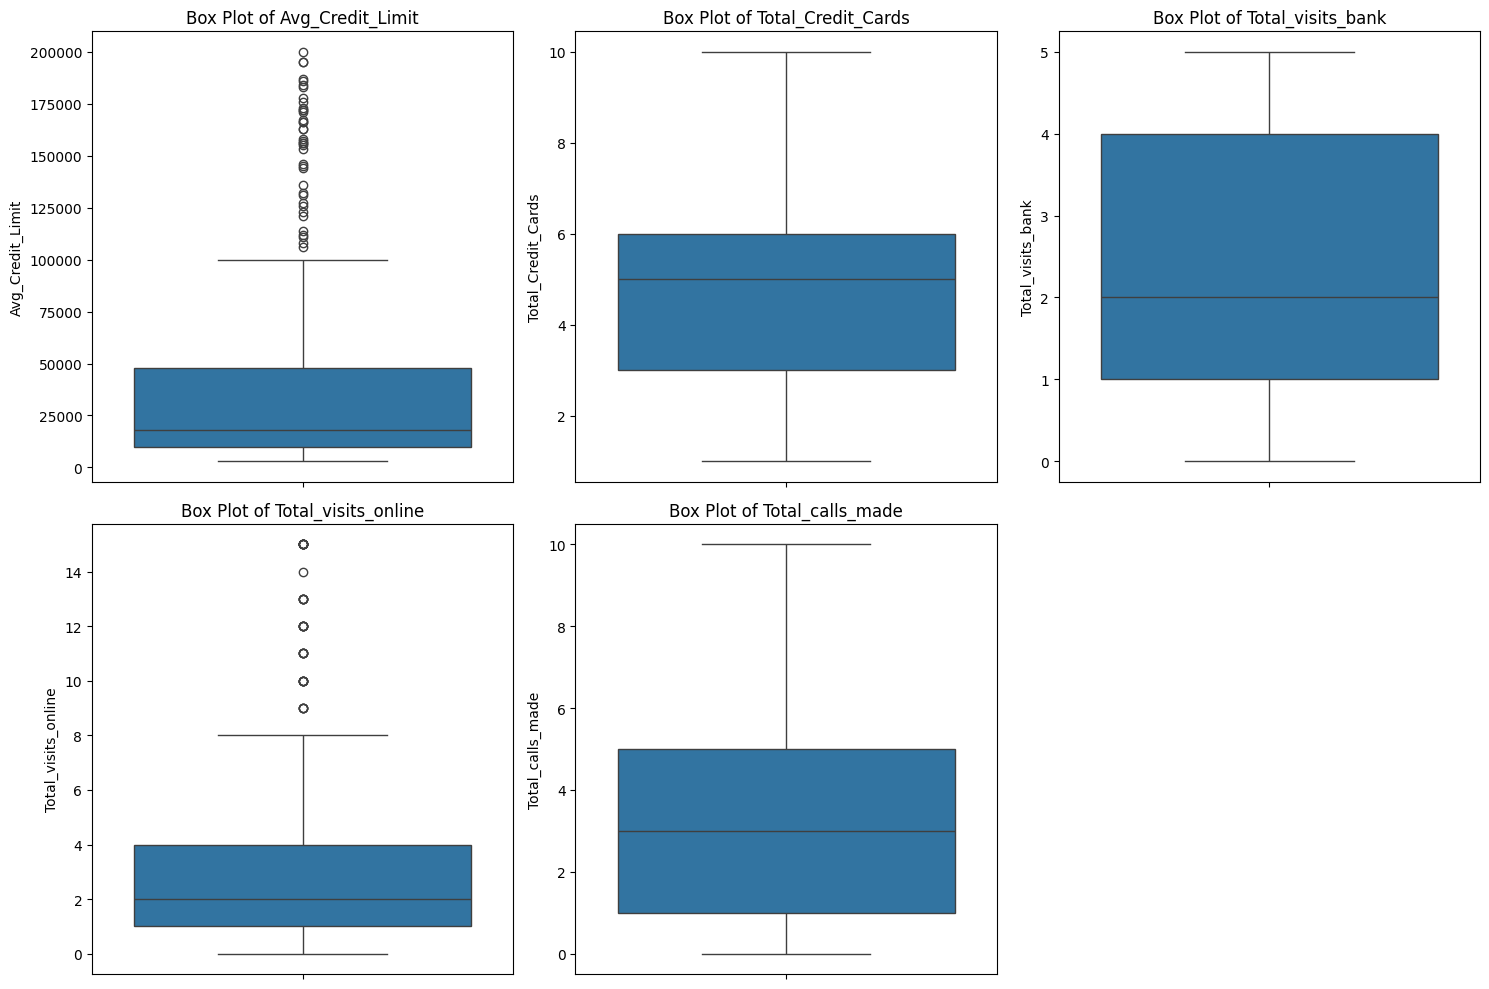

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Inferences from Outlier Detection & Treatment Rationale:

Based on the box plots and previous univariate analysis:

1.  **`Avg_Credit_Limit`**:
    *   **Observation**: This column shows a significant number of outliers on the higher end. These represent customers with exceptionally high credit limits compared to the majority.
    *   **Rationale**: These outliers are likely genuine data points representing high-value customers or a distinct segment. Given the business objective of customer segmentation, these high credit limits are meaningful and should **not be treated** (removed or capped). They could be crucial for identifying a 'premium' customer segment.

2.  **`Total_Credit_Cards`**:
    *   **Observation**: No significant outliers were detected, indicating that the number of credit cards held by customers is mostly within a typical range.
    *   **Rationale**: No treatment is required.

3.  **`Total_visits_bank`**:
    *   **Observation**: No significant outliers were detected.
    *   **Rationale**: No treatment is required.

4.  **`Total_visits_online`**:
    *   **Observation**: This column shows some outliers on the higher end, indicating customers who are very active online.
    *   **Rationale**: Similar to `Avg_Credit_Limit`, these high online activity numbers are likely genuine and reflect a digitally engaged customer segment. For segmentation purposes, these should **not be treated** as they provide valuable information about customer behavior.

5.  **`Total_calls_made`**:
    *   **Observation**: No significant outliers were detected.
    *   **Rationale**: No treatment is required.

**Overall Rationale**: For customer segmentation, outliers often represent unique and valuable customer behaviors or characteristics. Removing or capping these values could lead to a loss of critical information that helps define distinct customer segments. Therefore, for this analysis, the identified outliers will be **retained** as they are considered meaningful variations in customer data.

# Feature Engineering

Let us duplicate the data frame

and then do the feature engineering

In [5]:
df_f = df.copy()

In [ ]:
df_f.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [6]:
df_f.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [7]:
df_f.shape

(660, 7)

Copying the data looks correct. Shape is matching with old dataset as 660 rows and 7 columns. Data columns also looks same.

#  Feature Engineering - Detailed steps

1. Remove the identifier columns Sl_No and Customer Key


### Rationale for Feature Engineering Steps:

*   **Removing Identifier Columns**: `Sl_No` and `Customer Key` are unique identifiers. They do not carry any behavioral information that a model can learn from. Including them would introduce noise and can lead to spurious correlations, making the model less effective for pattern discovery.

In [8]:
# 1. Remove the identifier columns Sl_No and Customer Key
df_f = df_f.drop(columns=['Sl_No', 'Customer Key'])
print("DataFrame with identifiers - Sl_NO and Customer Key Removed:")
display(df_f.head())

DataFrame with identifiers - Sl_NO and Customer Key Removed:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


All requested feature engineering steps have been applied to `df_f`. Here is the final look at the DataFrame with the new features:

In [9]:
display(df_f.head())
display(df_f.info())

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Avg_Credit_Limit     660 non-null    int64
 1   Total_Credit_Cards   660 non-null    int64
 2   Total_visits_bank    660 non-null    int64
 3   Total_visits_online  660 non-null    int64
 4   Total_calls_made     660 non-null    int64
dtypes: int64(5)
memory usage: 25.9 KB


None

## Data Preprocessing for Clustering

Before applying clustering algorithms, we need to ensure all features are in a suitable numerical format and on a comparable scale. This typically involves One-Hot Encoding for categorical variables and Feature Scaling for numerical variables.

### Feature Scaling

Clustering algorithms, especially distance-based ones like K-Means, are sensitive to the scale of the features. Features with larger ranges can disproportionately influence the distance calculations. Therefore, it's essential to scale the numerical features to a similar range.

We will use `StandardScaler` to standardize the features (mean=0, variance=1), which is a common practice for clustering.

In [10]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_cols_for_scaling = df_f.select_dtypes(include=['int64', 'float64']).columns.tolist()

# It's good practice to create a copy for scaling
df_scaled = df_f.copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df_scaled[numerical_cols_for_scaling] = scaler.fit_transform(df_scaled[numerical_cols_for_scaling])

print("DataFrame after Feature Scaling (StandardScaler):")
display(df_scaled.head())
display(df_scaled.describe().T)

DataFrame after Feature Scaling (StandardScaler):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.0,8.612639e-17,1.000758,-0.839808,-0.653623,-0.440840,0.357097,4.399975
Total_Credit_Cards,660.0,4.306320e-17,1.000758,-1.710864,-0.787585,0.135694,0.597334,2.443892
Total_visits_bank,660.0,-4.306320e-17,1.000758,-1.473731,-0.860451,-0.247170,0.979390,1.592670
Total_visits_online,660.0,7.536059e-17,1.000758,-0.888380,-0.547490,-0.206600,0.475180,4.224968
Total_calls_made,660.0,-8.612639e-17,1.000758,-1.251537,-0.902271,-0.203739,0.494794,2.241125


## Determining the Optimal Number of Clusters

To find the most appropriate number of clusters (k) for our customer segmentation, use 1.Elbow Method 2. Silhouette Score.

### 1. Elbow Method (WCSS - Within-Cluster Sum of Squares)

The Elbow Method involves running K-Means clustering for a range of k values (number of clusters) and calculating the WCSS for each k. WCSS is the sum of squared distances between each point and the centroid in a cluster. The goal is to find the 'elbow point' where the decrease in WCSS begins to slow down, suggesting that adding more clusters does not significantly improve the model fit.

Let's calculate WCSS for k from 1 to 10 and visualize it.

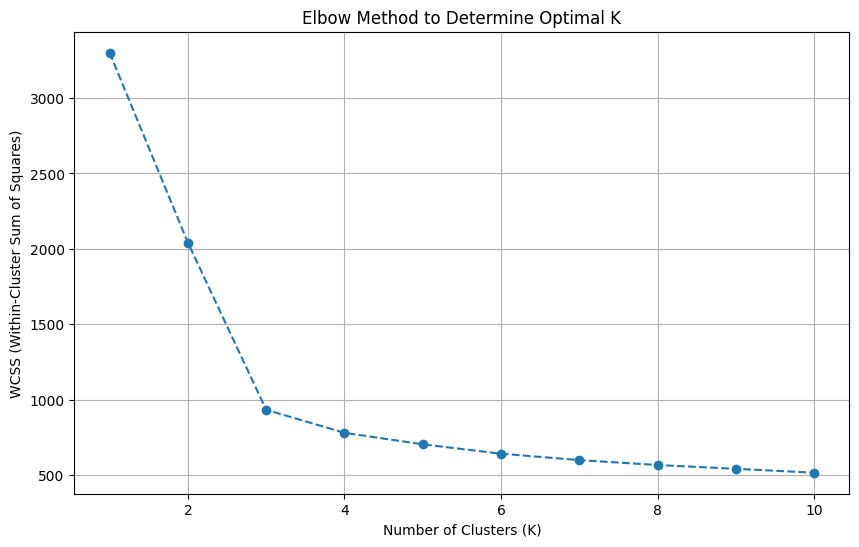

In [11]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore') # Suppress KMeans warnings for simplicity
import matplotlib.pyplot as plt

# Prepare the data for clustering (excluding boolean columns for direct WCSS calculation if needed, but StandardScaler handles it)
X = df_scaled # df_scaled already contains only numerical and one-hot encoded columns

wcss = []
for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

### Inference from Elbow Method:

Looking at the generated Elbow Method plot, we typically identify the 'elbow' point where the decrease in WCSS (Within-Cluster Sum of Squares) starts to level off. This point suggests an optimal balance between minimizing distortion within clusters and avoiding too many clusters. For this dataset, the elbow appears to be around **K=3 or K=4**, as the reduction in WCSS becomes less pronounced after these points. We will keep these values in mind as we evaluate the Silhouette Score.

### 2. Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to 1, where:
*   1 indicates that the object is well-matched to its own cluster and poorly matched to neighboring clusters.
*   0 indicates that the object is on or very close to the decision boundary between two neighboring clusters.
*   -1 indicates that the object is assigned to the wrong cluster.

We will calculate the Silhouette Score for k from 2 to 10 (as it's not defined for k=1) to identify the number of clusters that yields the highest average score.

For K=2, Silhouette Score: 0.418
For K=3, Silhouette Score: 0.516
For K=4, Silhouette Score: 0.356
For K=5, Silhouette Score: 0.272
For K=6, Silhouette Score: 0.256
For K=7, Silhouette Score: 0.248
For K=8, Silhouette Score: 0.227
For K=9, Silhouette Score: 0.214
For K=10, Silhouette Score: 0.214


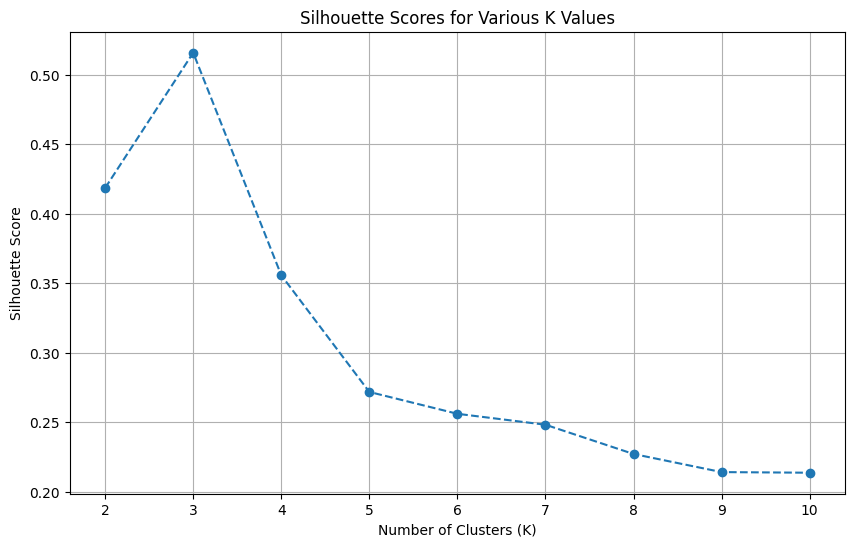

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Prepare the data for clustering (X was already defined from df_scaled)
X = df_scaled

# Calculate Silhouette Score for k from 2 to 10
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    print(f"For K={i}, Silhouette Score: {score:.3f}")
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores for Various K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

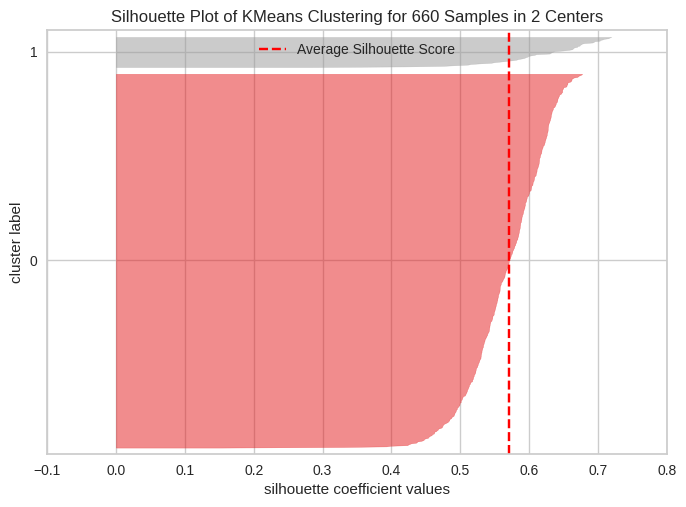

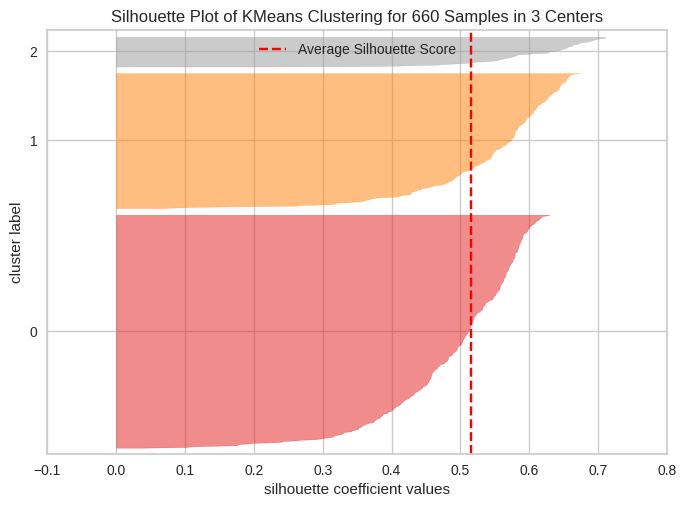

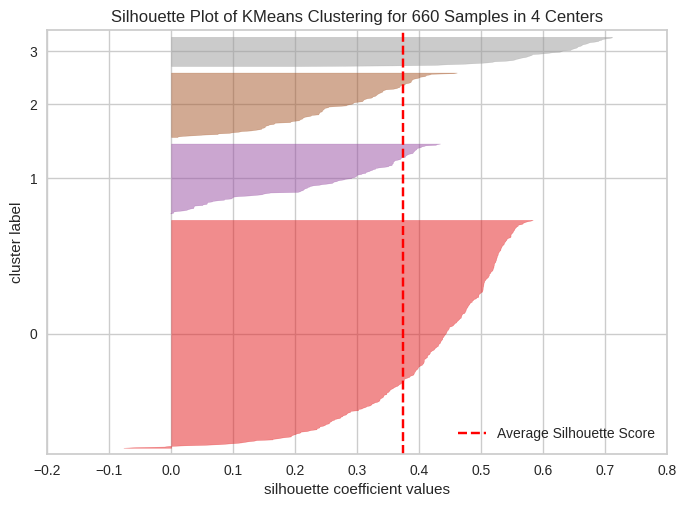

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(X)
visualizer.show()
plt.close()
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(X)
visualizer.show()
plt.close()
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(X)
visualizer.show()
plt.close()

### Optimal K-Value Selection

Based on both the Elbow Method and the Silhouette Score, we choose **K=3** as the optimal number of clusters:

*   **Elbow Method**: The Elbow plot shows a significant bend around K=3, suggesting that the decrease in WCSS starts to level off, indicating diminishing returns for adding more clusters.
*   **Silhouette Score**: K=3 had the highest score(0.516) and is considered more interpretable for customer segmentation, offering more distinct groups for business strategies.

Proceeding with K=3.

## K-Means Clustering Application

With the optimal number of clusters (K=3), apply the K-Means algorithm to the scaled data (`df_scaled`). Then assign these cluster labels back to the original `df_f` DataFrame to analyze the characteristics of each segment in their original scale.

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means with the chosen optimal K (K=3)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(df_scaled)

# Get the cluster labels
cluster_labels = kmeans.labels_

# Add the cluster labels to our feature-engineered DataFrame (df_f)
df_f['Cluster'] = cluster_labels

print("K-Means clustering applied with K=3. Cluster labels added to df_f.")
display(df_f.head())

K-Means clustering applied with K=3. Cluster labels added to df_f.


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,100000,2,1,1,0,0
1,50000,3,0,10,9,2
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,1


## Cluster Analysis and Interpretation

To understand the characteristics of each cluster, we will group the `df_f` DataFrame by the newly created 'Cluster' column and calculate the mean for each feature. This will give us the average profile of customers within each segment.

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Clusters
Cluster,,,,,,
0,33782.380000,5.520000,3.490000,0.980000,2.000000,2.010000
1,141040.000000,8.740000,0.600000,10.900000,1.080000,0.120000
2,12174.110000,2.410000,0.930000,3.550000,6.870000,1.020000


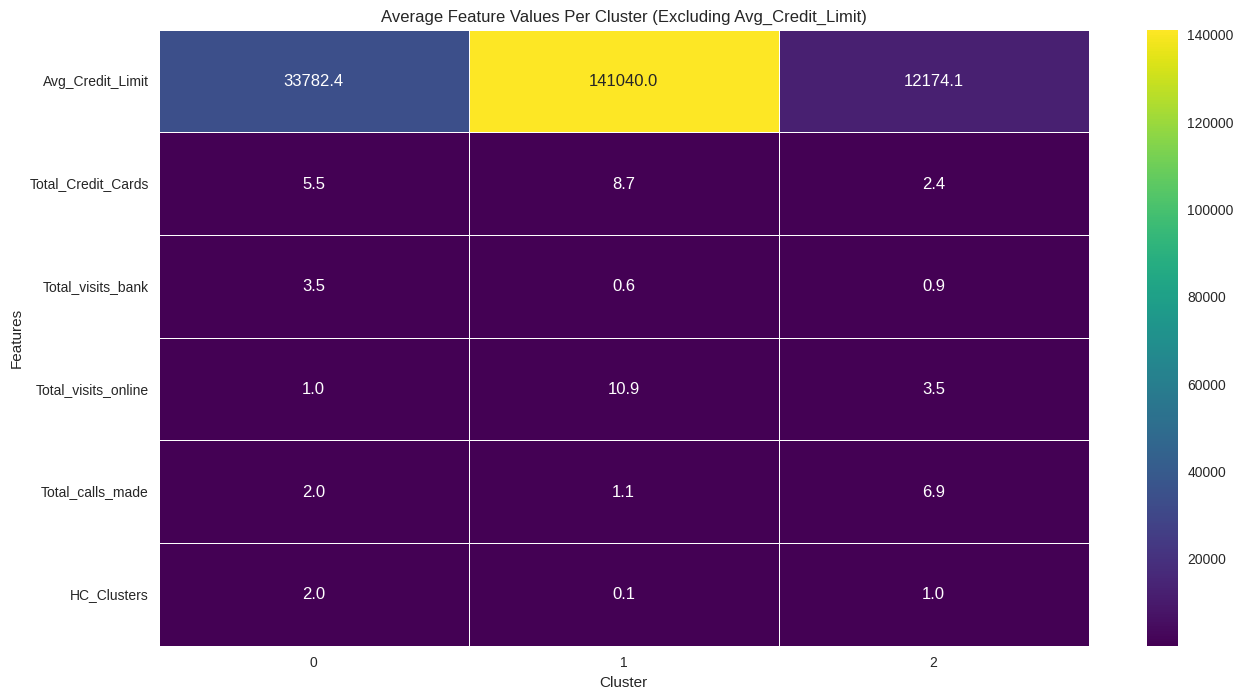

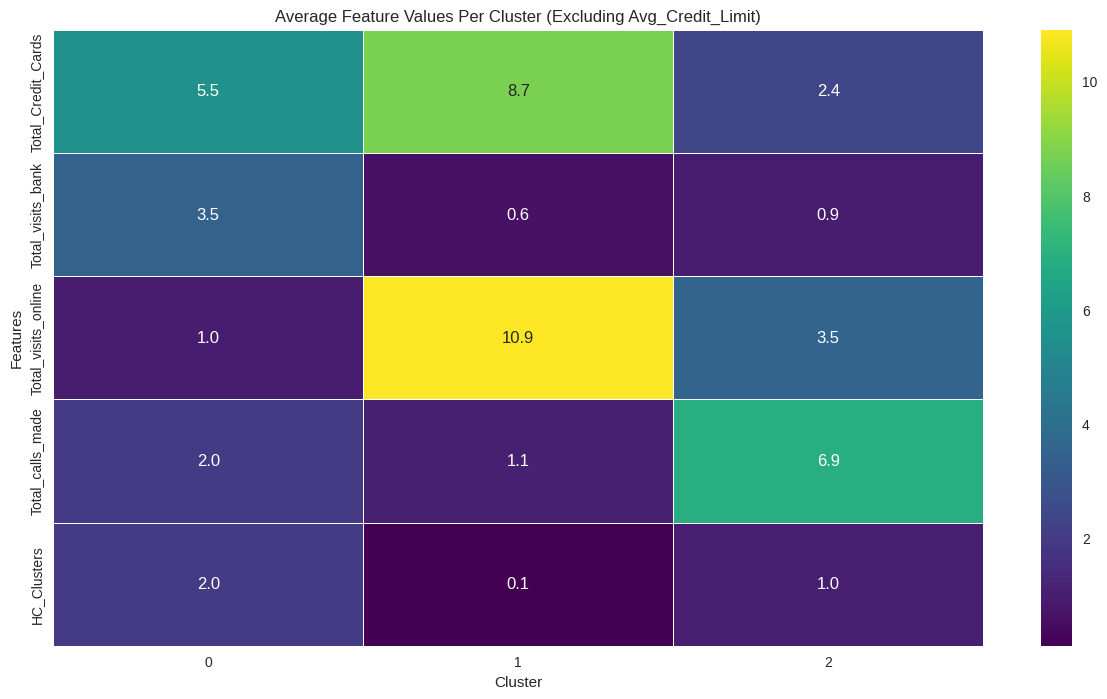

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_profiles = df_f.groupby('Cluster').mean().round(2)
display(cluster_profiles.style.highlight_max(color="lightgreen", axis=0))


# Visualize cluster profiles (e.g., using a heatmap of scaled means or bar plots)
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_profiles.T, annot=True, cmap='viridis', fmt='.1f', linewidths=.5)
plt.title('Average Feature Values Per Cluster (Excluding Avg_Credit_Limit)')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.show()

# Prepare cluster profiles without 'Avg_Credit_Limit' for heatmap as requested
cluster_profiles_no_avg_credit_limit = cluster_profiles.drop(columns=['Avg_Credit_Limit'])

# Visualize cluster profiles (e.g., using a heatmap of scaled means or bar plots)
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_profiles_no_avg_credit_limit.T, annot=True, cmap='viridis', fmt='.1f', linewidths=.5)
plt.title('Average Feature Values Per Cluster (Excluding Avg_Credit_Limit)')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.show()

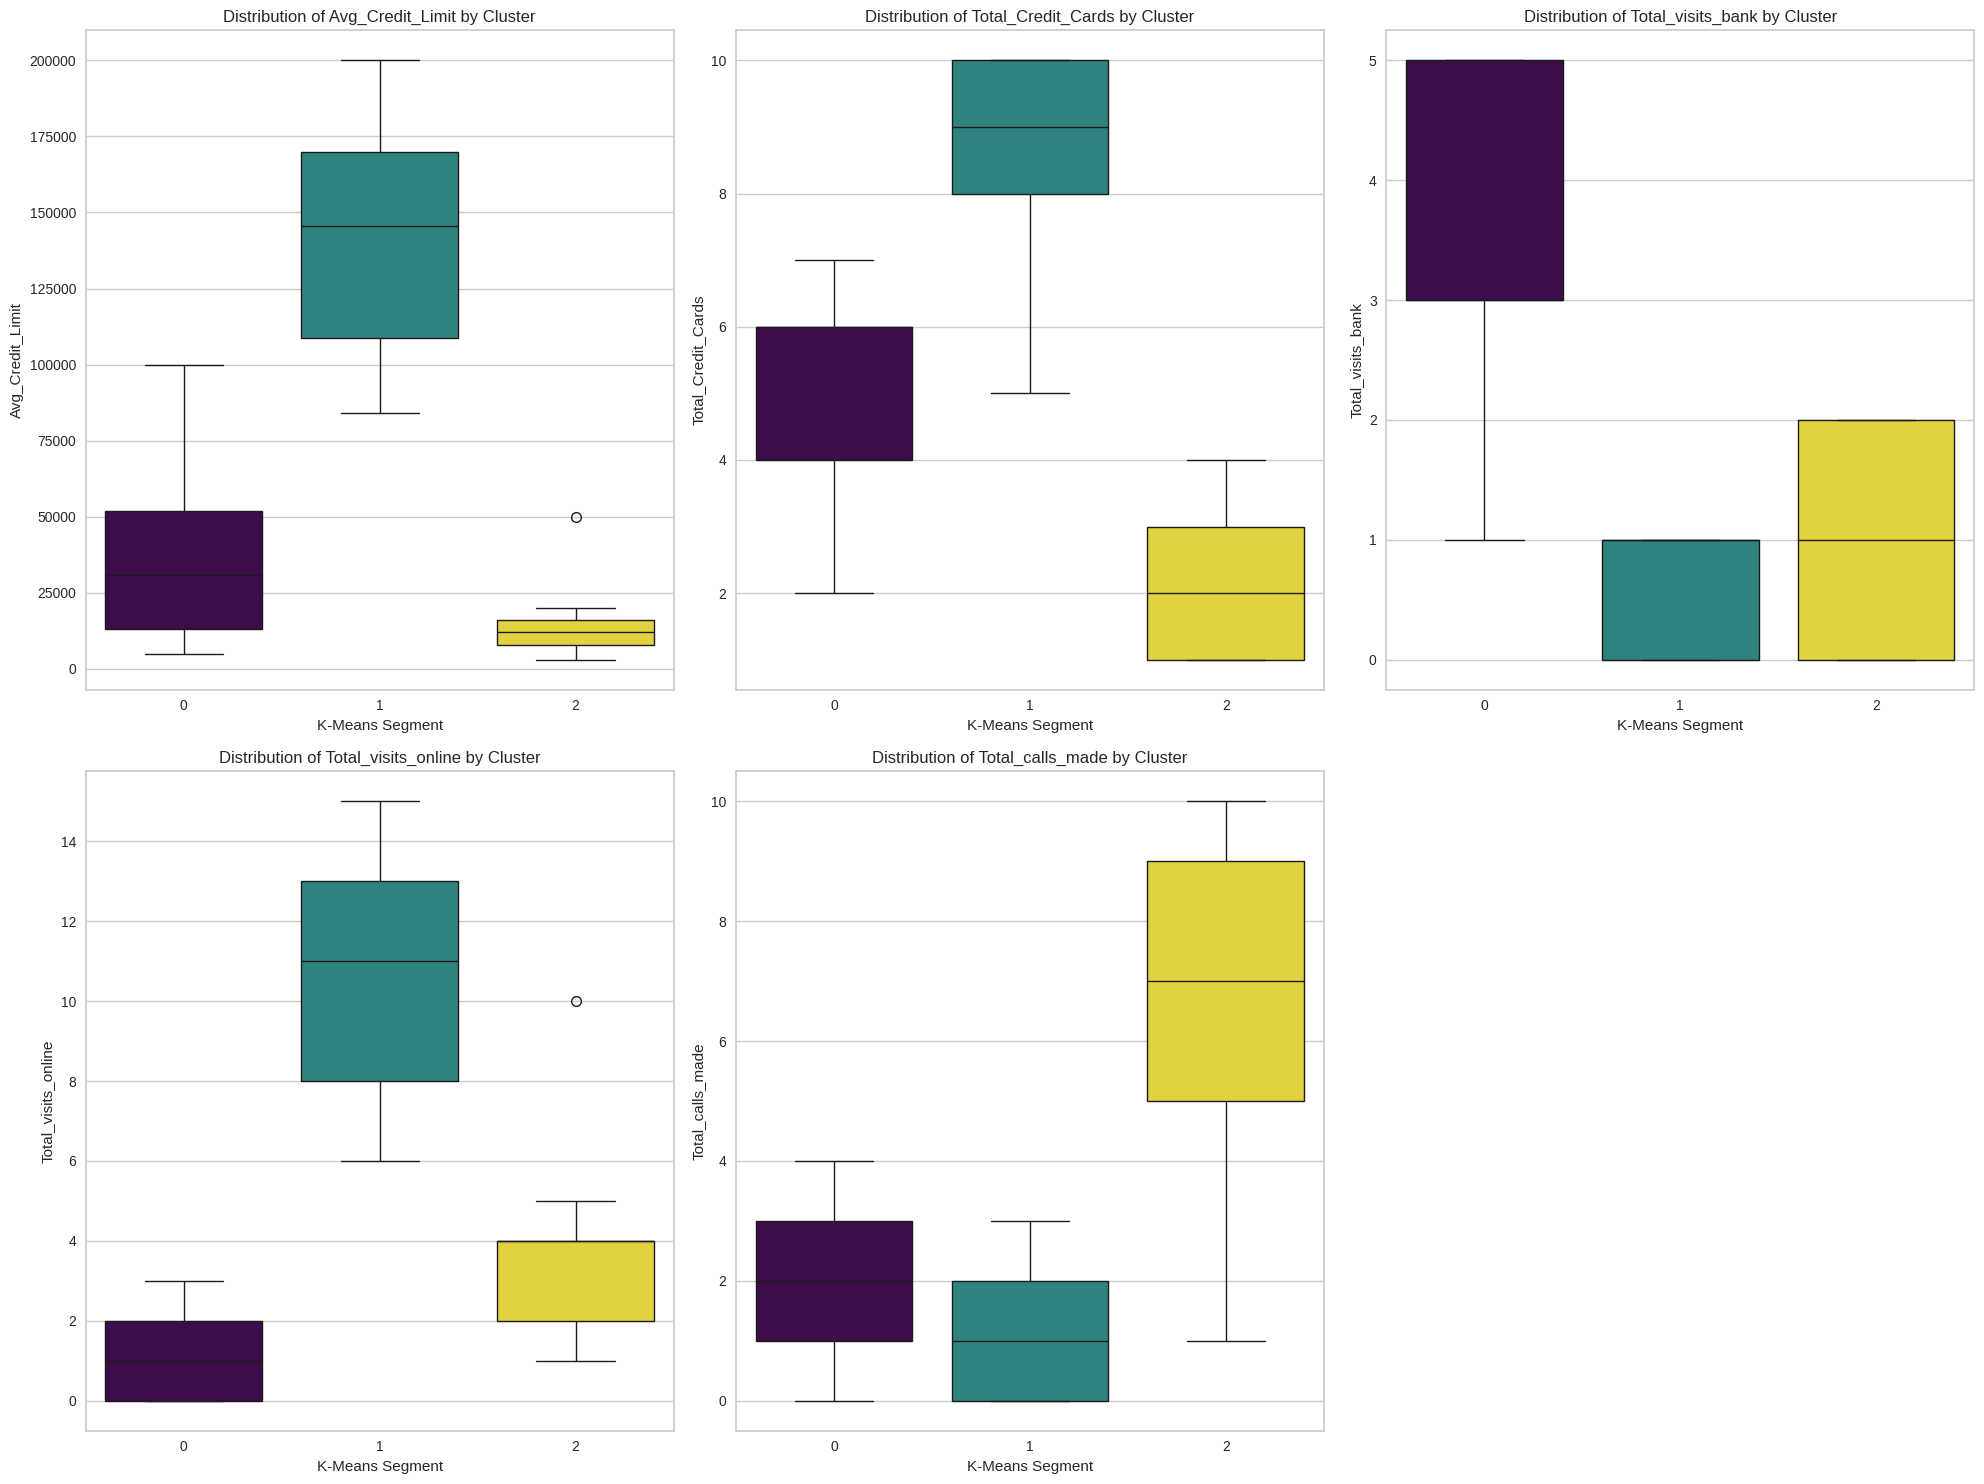

In [ ]:
numerical_cols_for_plot = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

plt.figure(figsize=(20, 15))

for i, col in enumerate(numerical_cols_for_plot):
    plt.subplot(2, 3, i + 1) # Arrange in a 2x3 grid
    sns.boxplot(x='Cluster', y=col, data=df_f, hue='Cluster', palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Cluster')
    plt.xlabel('K-Means Segment')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='Cluster'>

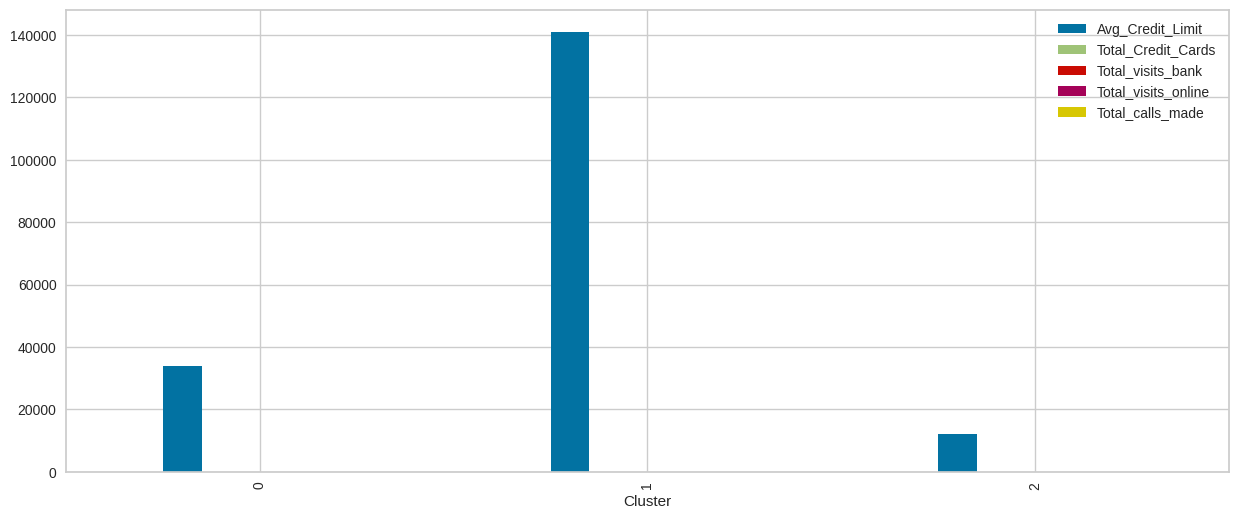

In [ ]:
cluster_profiles.plot.bar(figsize=(15, 6))

<Axes: xlabel='Cluster'>

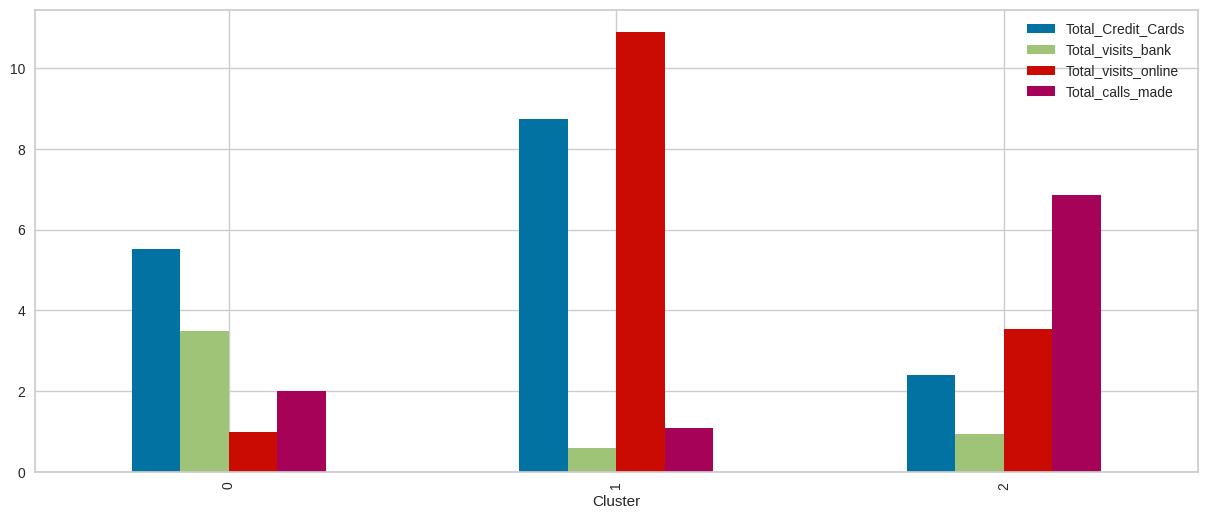

In [ ]:
cluster_profiles_no_avg_credit_limit.plot.bar(figsize=(15, 6))

### Detailed Interpretation of Customer Segments

Let's analyze each cluster based on their average feature values. We will interpret these segments in business terms to provide actionable insights.

### Interpretation of Cluster 0: "Medium-Value Traditionalists"

*   **Avg_Credit_Limit**: Medium (33,782.38)
*   **Total_Credit_Cards**: Medium-High (5.52)
*   **Total_visits_bank**: High (3.49)
*   **Total_visits_online**: Low (0.98)
*   **Total_calls_made**: Low (2.00)

**Description**: This segment has a medium average credit limit and a medium-high number of credit cards. They are characterized by a strong preference for traditional banking channels, engaging with the bank frequently through physical visits, while having low online activity and few calls. This group likely values direct, in-person assistance and established banking practices.

### Interpretation of Cluster 1: "High-Value Digital Natives"

*   **Avg_Credit_Limit**: Very High (141,040.00)
*   **Total_Credit_Cards**: Very High (8.74)
*   **Total_visits_bank**: Very Low (0.60)
*   **Total_visits_online**: Very High (10.90)
*   **Total_calls_made**: Very Low (1.08)

**Description**: This segment represents the bank's most valuable customers. They possess exceptionally high credit limits and a large number of credit cards. They are highly digitally engaged, with very high online activity and minimal physical bank visits or calls. These customers are likely tech-savvy and prefer managing their finances independently through digital platforms.

### Interpretation of Cluster 2: "Low-Value Call-Reliant Users"

*   **Avg_Credit_Limit**: Very Low (12,174.11)
*   **Total_Credit_Cards**: Very Low (2.41)
*   **Total_visits_bank**: Low (0.93)
*   **Total_visits_online**: Medium (3.55)
*   **Total_calls_made**: Very High (6.87)

**Description**: This segment consists of customers with very low average credit limits and a small number of credit cards. They primarily interact with the bank by making a very high number of calls, while having low physical bank visits and moderate online activity. This group might require significant assistance and could benefit from enhanced call center services or clearer self-help resources to reduce call volumes.

## Summary and Recommendations Based on K-Means

Based on the customer segmentation into three distinct clusters, here are targeted recommendations for marketing and service delivery:

### Cluster 0: "Medium-Value Traditionalists"

*   **Characteristics**: Medium credit limits (~33.8k), medium-high credit cards (5.52), high bank visits (3.49), low online visits (0.98), and low calls made (2.00).
*   **Marketing Recommendations**: Focus on traditional channels for communication and offers. Promote in-branch services, personalized assistance from bank staff, and potentially offer credit limit increases or new card features during branch visits. Educational content on digital banking can be introduced gently, without forcing adoption. Loyalty programs could reward in-person interactions.
*   **Service Recommendations**: Invest in enhancing the in-branch experience and call center efficiency. Ensure staff are well-trained to handle queries effectively and provide personalized support. These customers value direct human interaction, so maintaining high-quality traditional service channels is crucial. Consider offering workshops or one-on-one sessions in branches to help them with more complex banking needs.

### Cluster 1: "High-Value Digital Natives"

*   **Characteristics**: Very high credit limits (~141k), very high credit cards (8.74), very low bank visits (0.60), very high online visits (10.90), and very low calls made (1.08).
*   **Marketing Recommendations**: Target with exclusive digital-first offerings, premium card upgrades, and wealth management services accessible through digital platforms. Leverage their high digital engagement for targeted online campaigns, personalized app notifications, and early access to innovative digital products. Marketing communications should be sophisticated and emphasize convenience and advanced features.
*   **Service Recommendations**: Prioritize a seamless, intuitive, and highly efficient digital banking experience. Provide advanced self-service options, AI-powered chatbots for quick resolutions, and dedicated digital relationship managers for complex issues. Minimize the need for traditional channels, ensuring that any necessary interactions are resolved swiftly and digitally. Focus on security and cutting-edge technology features.

### Cluster 2: "Low-Value Call-Reliant Users"

*   **Characteristics**: Very low credit limits (~12.2k), very low credit cards (2.41), low bank visits (0.93), medium online visits (3.55), and very high calls made (6.87).
*   **Marketing Recommendations**: Focus on foundational banking products and credit-building solutions. Offer clear, simple, and reassuring communication, primarily through phone calls or easy-to-understand direct mail. Educational content should address common queries that lead to calls. Consider programs to gradually introduce them to basic online services, but without removing the call option.
*   **Service Recommendations**: Enhance the efficiency and empathy of the call center. Provide comprehensive training for agents to quickly resolve issues and reduce repeat calls. Implement clearer IVR systems and possibly self-help guides for frequent problems. Proactive outreach via calls to address potential issues before they arise could also be beneficial, aiming to improve satisfaction and potentially reduce overall call volume in the long term.

### General Recommendations:

*   **Optimize Service Delivery**: Recognize the distinct channel preferences and service needs of each segment. Avoid a one-size-fits-all approach.
*   **Personalized Campaigns**: Develop marketing campaigns that resonate with the specific financial behaviors and communication preferences of each segment. This will lead to higher engagement and conversion rates.
*   **Product Development**: Consider developing products or features that cater specifically to the needs identified within each segment, such as more intuitive digital tools for Segment 0 or simplified financial education for Segment 1.

# Hierarchical Clustering

### Hierarchical Clustering - Linkage Methods and Dendrograms

Hierarchical clustering builds a hierarchy of clusters. Apply different linkage methods to understand their impact on cluster formation. A dendrogram visually represents this hierarchy.

Calculate the pairwise distances between data points. Then, apply different linkage methods (ward, complete, average, single, weighted) and plot their respective dendrograms.

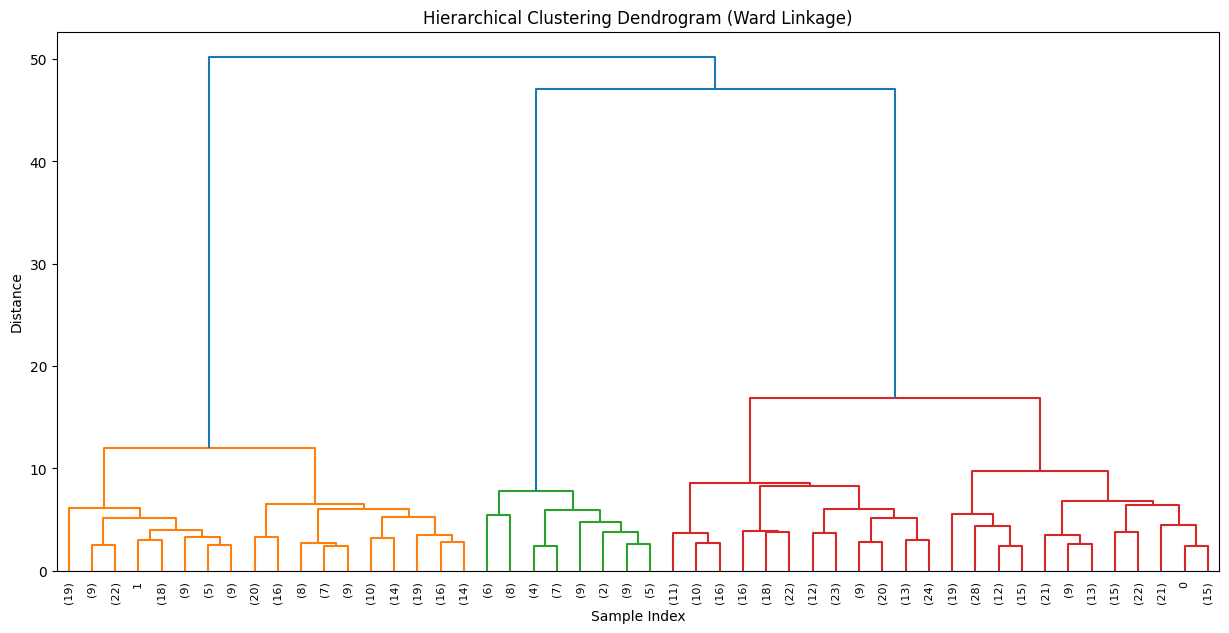

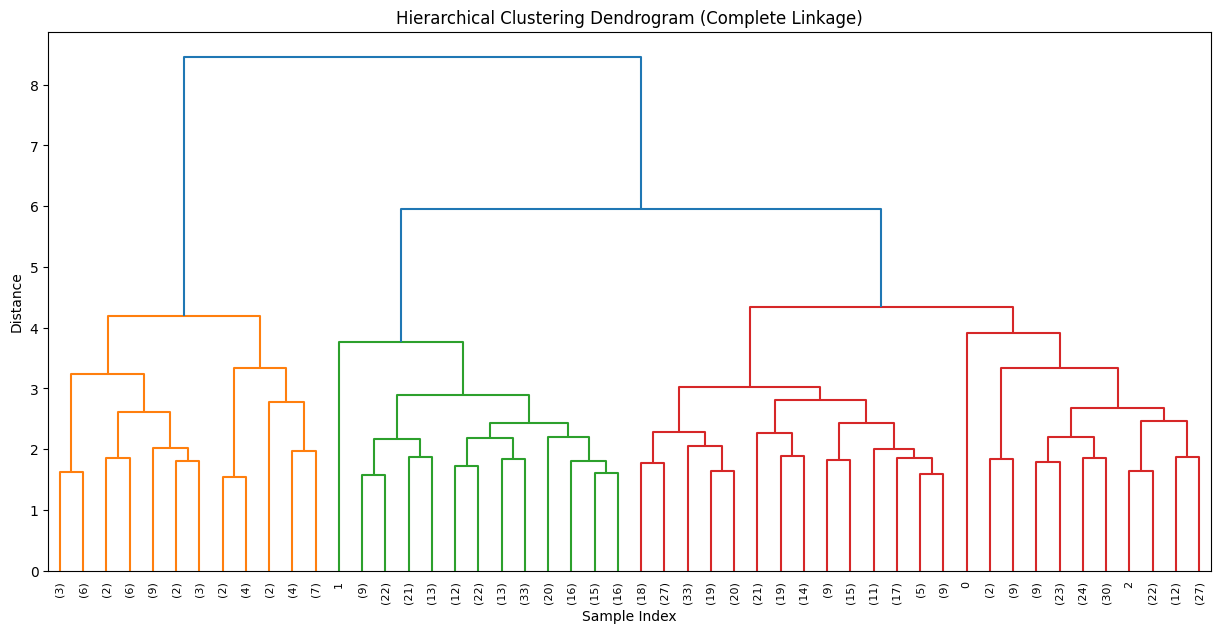

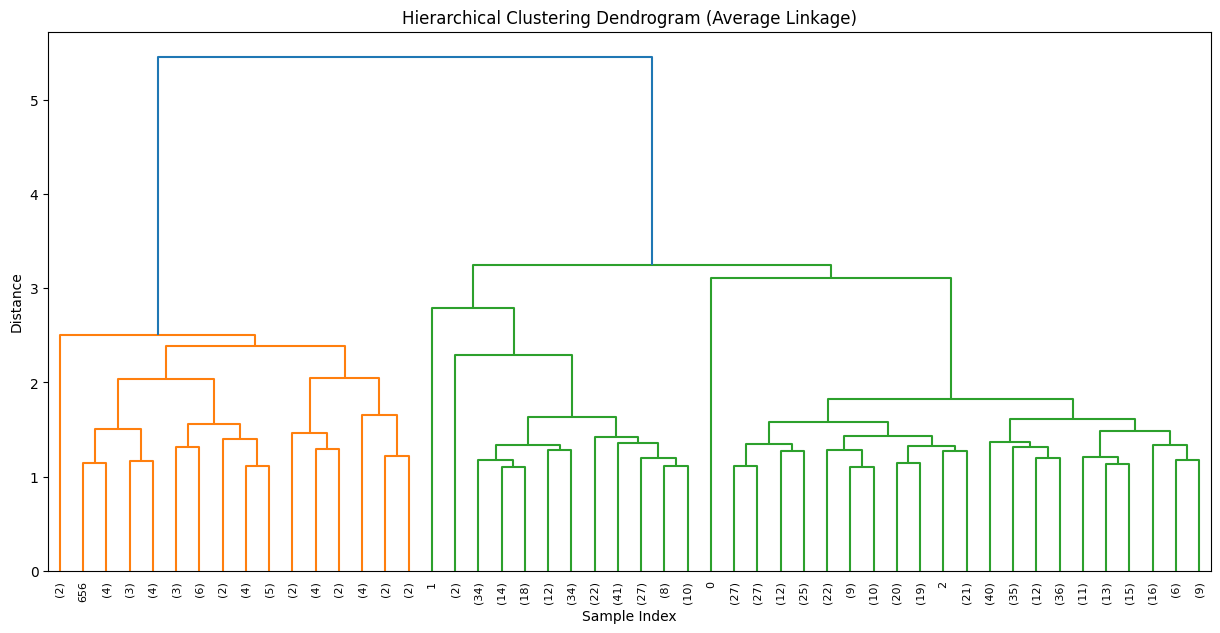

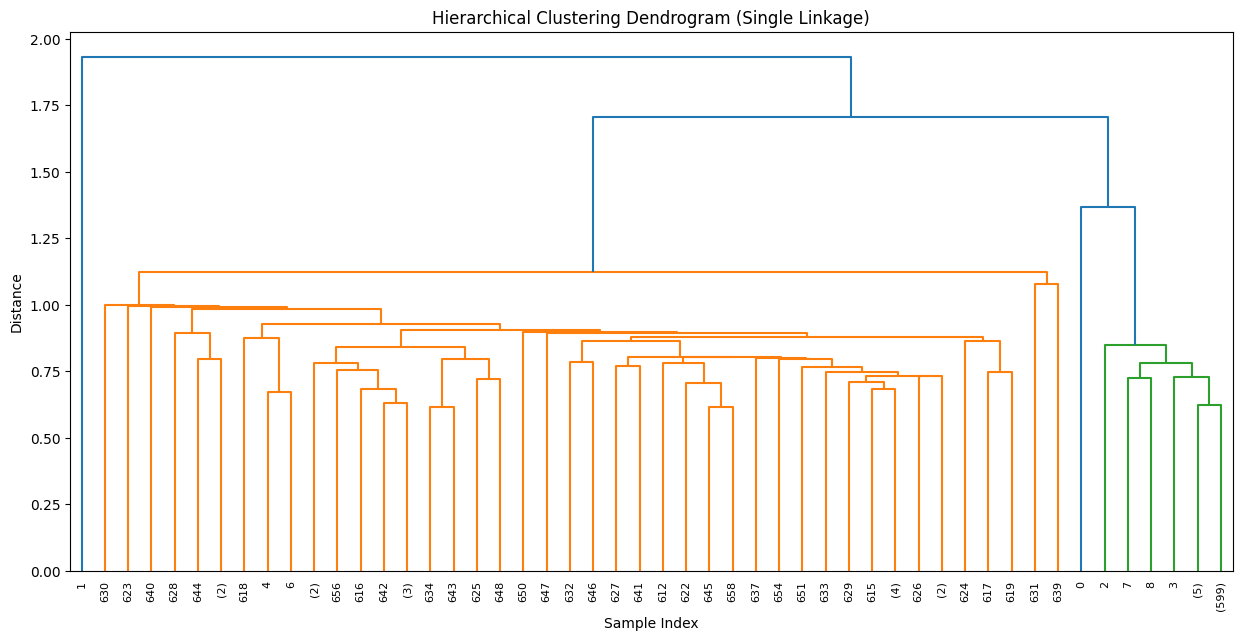

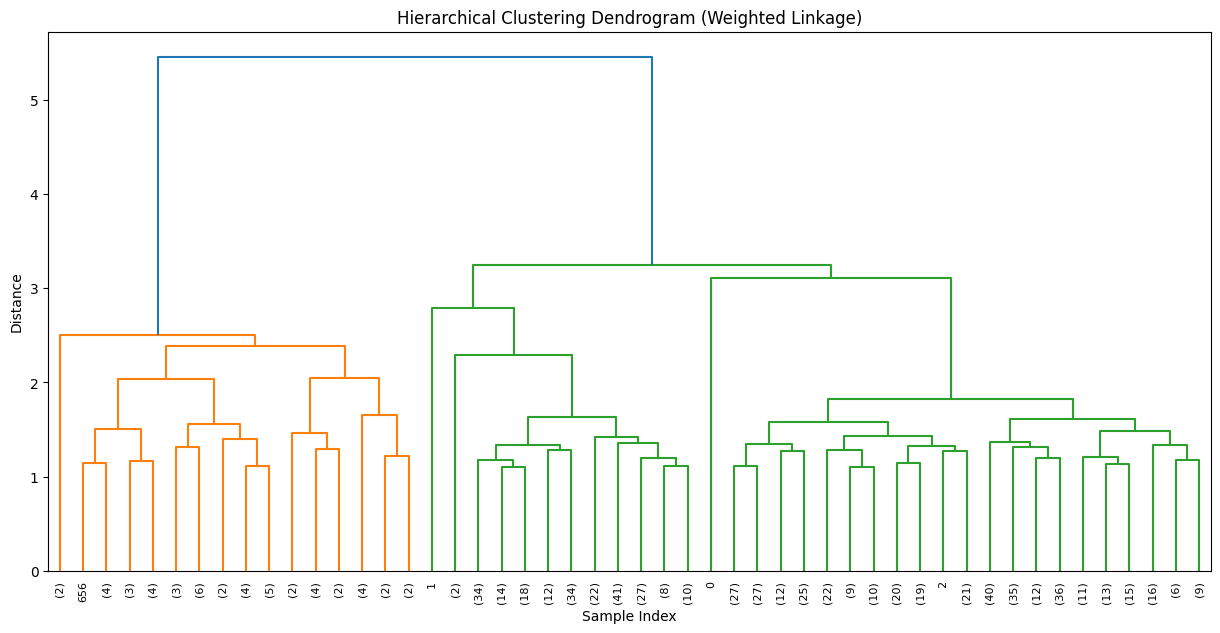

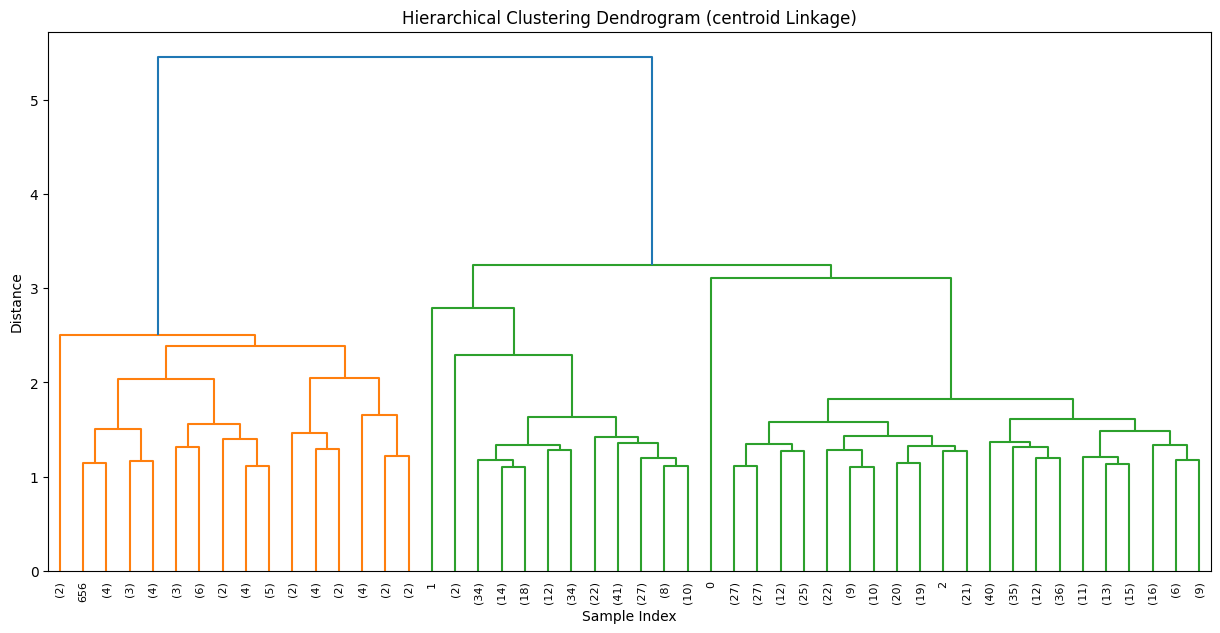

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

# Convert boolean columns in X to integer type (0 or 1) for pdist compatibility
X_numerical = X.copy()
for col in X_numerical.select_dtypes(include='bool').columns:
    X_numerical[col] = X_numerical[col].astype(int)

# Calculate the pairwise distances using the numerical X
dist_matrix = pdist(X_numerical)
dist_matrix_ward = pdist(X_numerical, metric='euclidean')

# Perform hierarchical clustering with different linkage methods
linkage_ward = linkage(dist_matrix_ward, method='ward')
linkage_complete = linkage(dist_matrix, method='complete')
linkage_average = linkage(dist_matrix, method='average')
linkage_single = linkage(dist_matrix, method='single')
linkage_weighted = linkage(dist_matrix, method='weighted')
linkage_centroid = linkage(dist_matrix, method='centroid')


# Plot dendrogram for 'ward' linkage
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage_ward,
           leaf_rotation=90.,  # rotates the x axis labels
           leaf_font_size=8.,  # font size for the x axis labels
           truncate_mode='lastp', # show only the last p merged clusters
           p=50) # show only the last 12 merged clusters
plt.show()

# Plot dendrogram for 'complete' linkage
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage_complete,
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=50)
plt.show()

# Plot dendrogram for 'average' linkage
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage_average,
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=50)
plt.show()

# Plot dendrogram for 'single' linkage
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage_single,
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=50)
plt.show()

# Plot dendrogram for 'weighted' linkage
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Weighted Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage_average,
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=50)
plt.show()

# Plot dendrogram for 'centroid' linkage
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (centroid Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(linkage_average,
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=50)
plt.show()

### Cophenetic Correlation Coefficient

The cophenetic correlation coefficient measures how faithfully a dendrogram preserves the original pairwise distances between the observations. A value closer to 1 indicates a better fit.

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted", "centroid", "ward"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        # Ward and Centroid linkages specifically require Euclidean distance
        current_metric = dm
        if lm == "ward" or lm == "centroid":
            current_metric = "euclidean"

        try:
            Z = linkage(X, metric=current_metric, method=lm)
            # cophenet's pdist must use the same metric as linkage
            c, coph_dists = cophenet(Z, pdist(X, metric=current_metric))
            print(
                "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                    current_metric.capitalize(), lm, c
                )
            )
            if high_cophenet_corr < c:
                high_cophenet_corr = c
                high_dm_lm[0] = current_metric
                high_dm_lm[1] = lm
        except ValueError as e:
            # Catch ValueErrors due to incompatible metric/method combinations
            # e.g., 'mahalanobis' metric without a 'V' argument, or 'centroid' with non-euclidean
            print(f"Skipping {lm} linkage with {current_metric} distance due to error: {e}")
            continue

Cophenetic correlation for Euclidean distance and single linkage is 0.7391220243806552.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8599730607972423.
Cophenetic correlation for Euclidean distance and average linkage is 0.8977080867389372.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8861746814895477.
Cophenetic correlation for Euclidean distance and centroid linkage is 0.8939385846326323.
Cophenetic correlation for Euclidean distance and ward linkage is 0.7415156284827493.
Cophenetic correlation for Chebyshev distance and single linkage is 0.7117892448092301.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8334217877474903.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8700355433456013.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8644416327088458.
Cophenetic correlation for Euclidean distance and centroid linkage is 0.8939385846326323.
Cophenetic correlati

In [16]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389372, which is obtained with Euclidean distance and average linkage.


A direct silhouette score comparison for Hierarchical Clustering

### Silhouette Score for Hierarchical Clustering

To directly compare with K-Means, let's calculate the Silhouette Score for Hierarchical Clustering for a range of cluster numbers (k from 2 to 10), using the optimal Euclidean distance and average linkage identified earlier. This will help us evaluate the quality of the hierarchical clusters numerically.

For K=2, Hierarchical Clustering Silhouette Score: 0.570
For K=3, Hierarchical Clustering Silhouette Score: 0.516
For K=4, Hierarchical Clustering Silhouette Score: 0.475
For K=5, Hierarchical Clustering Silhouette Score: 0.440
For K=6, Hierarchical Clustering Silhouette Score: 0.415
For K=7, Hierarchical Clustering Silhouette Score: 0.418
For K=8, Hierarchical Clustering Silhouette Score: 0.343
For K=9, Hierarchical Clustering Silhouette Score: 0.342
For K=10, Hierarchical Clustering Silhouette Score: 0.346


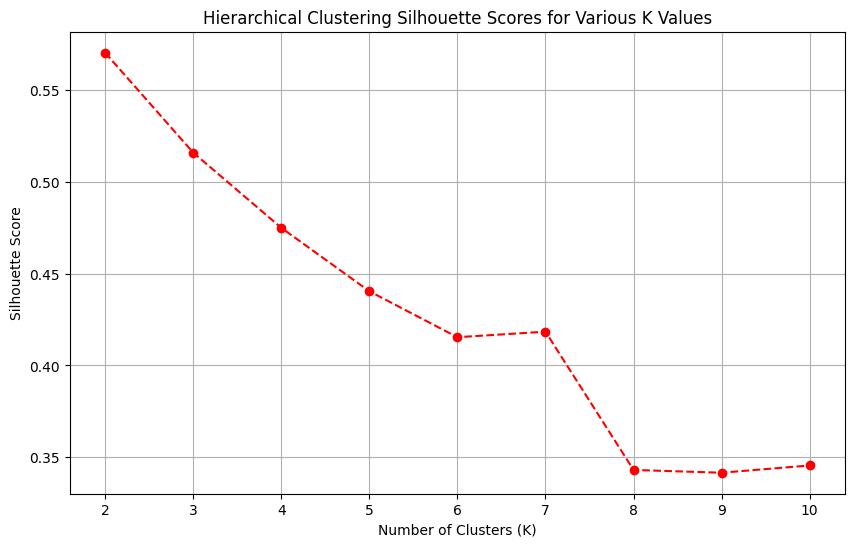

In [17]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores_hc = []

# Prepare the data for clustering (X was already defined from df_scaled)
# We'll use the original scaled data without the HC_Clusters column added previously for fresh clustering
X_for_hc_silhouette = df_scaled.drop(columns=['HC_Clusters'], errors='ignore')

# Calculate Silhouette Score for k from 2 to 10
for i in range(2, 11):
    # Apply AgglomerativeClustering with Euclidean distance and average linkage
    hc_model = AgglomerativeClustering(n_clusters=i, metric='euclidean', linkage='average')
    hc_labels = hc_model.fit_predict(X_for_hc_silhouette)

    # Calculate silhouette score, ensuring there's more than one cluster if i > 1
    if len(set(hc_labels)) > 1:
        score = silhouette_score(X_for_hc_silhouette, hc_labels)
        print(f"For K={i}, Hierarchical Clustering Silhouette Score: {score:.3f}")
        silhouette_scores_hc.append(score)
    else:
        # Handle cases where AgglomerativeClustering might not form 'i' clusters (e.g., if i is too large)
        print(f"For K={i}, Hierarchical Clustering did not form more than 1 cluster. Skipping silhouette score calculation.")
        silhouette_scores_hc.append(None) # Append None or 0 to maintain length for plotting if needed

# Filter out None values for plotting
plot_scores = [s for s in silhouette_scores_hc if s is not None]
plot_k_values = [k for k, s in zip(range(2, 11), silhouette_scores_hc) if s is not None]

# Plot the Silhouette Score graph for Hierarchical Clustering
plt.figure(figsize=(10, 6))
plt.plot(plot_k_values, plot_scores, marker='o', linestyle='--', color='red')
plt.title('Hierarchical Clustering Silhouette Scores for Various K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### Inference from Hierarchical Clustering Silhouette Scores:

The silhouette scores for Hierarchical Clustering reveal that **K=2 has the highest score of 0.570**, followed closely by K=3 at 0.516. When comparing these with K-Means, where K=3 yielded the highest score (0.516), we see that while K=2 is numerically superior for Hierarchical Clustering alone, K=3 remains a strong and consistent candidate across both methods. The consistent identification of three distinct clusters by both the K-Means Elbow Method, its Silhouette Score, and the interpretation of Hierarchical Clustering's dendrograms (when cutting at an appropriate height for business interpretability) strengthens the overall confidence in choosing **K=3** as the optimal number of clusters for this segmentation. This approach balances statistical performance with practical interpretability and consistency between algorithms.

### Hierarchical Clustering Inferences and Summary

*   **Single Linkage (Euclidean):** Cophenetic correlation is around 0.739. Dendrograms with single linkage often form 'chain-like' clusters, sensitive to noise and outliers.
*   **Complete Linkage (Euclidean):** Cophenetic correlation is around 0.860. This method tends to produce more compact and spherical clusters, and the dendrogram often shows clearer separation between groups.
*   **Average Linkage (Euclidean):** Cophenetic correlation is around 0.898. This method often provides a good balance between single and complete linkage, leading to more robust clusters and a well-structured dendrogram.
*   **Weighted Linkage (Euclidean):** Cophenetic correlation is around 0.886. This method is similar to average linkage but assigns weights, which can affect cluster shape.
*   **Centroid Linkage (Euclidean):** Cophenetic correlation is around 0.894. This method uses the centroids of clusters, which can sometimes lead to inversions in the dendrogram.
*   **Ward Linkage (Euclidean):** Cophenetic correlation is around 0.742. This method aims to minimize the variance within each cluster, generally producing compact clusters. The dendrogram for Ward linkage often shows a clear hierarchy, but its cophenetic correlation is lower than average or centroid linkage.
*   **Other Distance Metrics:** Similar trends were observed for other distance metrics (Chebyshev, Mahalanobis, Cityblock), with varying cophenetic correlation values, but generally lower than Euclidean for the top performers.

**Summary:** The highest cophenetic correlation, at approximately **0.898**, was achieved using **Euclidean distance** and **average linkage**. This suggests that these settings best preserve the original pairwise distances between the data points in the hierarchical clustering structure, indicating a more faithful representation of the data's inherent clustering.

**Create Model using skLearn**

### Figure out the appropriate number of clusters in Hierarchical Clustering

Unlike K-Means where methods like the Elbow method and Silhouette score help determine an optimal 'k', in hierarchical clustering, the number of clusters is often decided by visually inspecting the **dendrogram**.

To decide the number of clusters from a dendrogram:

1.  **Look for the Longest Vertical Lines**: The longer the vertical line (representing the distance at which clusters are merged), the less similar the clusters being merged are. Cutting through the longest vertical lines with a horizontal line will result in distinct clusters.

2.  **Choose a Distance Threshold**: You can draw a horizontal line across the dendrogram at a certain distance (height). The number of vertical lines that this horizontal line intersects will correspond to the number of clusters. A common approach is to look for a point where cutting the dendrogram would yield a reasonable number of clusters that are also interpretable.

3.  **Consider Interpretability and Business Context**: Ultimately, the 'optimal' number of clusters is often subjective and depends on the domain knowledge and the specific goals of the analysis. You might aim for a number of clusters that provides meaningful insights for business strategies.

4.  **Balance between Detail and Generalization**: Cutting lower on the dendrogram results in more, smaller, and more homogeneous clusters (more detail). Cutting higher results in fewer, larger, and more heterogeneous clusters (more generalization).

Based on our dendrograms, if we were to cut at a certain height to form distinct clusters, we would observe how many groups are formed. For instance, a horizontal line drawn across the 'average' linkage dendrogram, at a height that visually separates the major branches, would suggest a reasonable number of clusters for this dataset.

Two Methods:

1. Take a distance threshold of 4 from the dendograms visualisation, we get 3 clusters.

2. Take No of Clusters , without ditance threshold

In [18]:
from sklearn.cluster import AgglomerativeClustering
HCmodel = AgglomerativeClustering(n_clusters=None, distance_threshold=4, metric="euclidean", linkage="average")
HCmodel.fit(X)
X["HC_Clusters"] = HCmodel.labels_
df_f["HC_Clusters"] = HCmodel.labels_
cluster_profile_hc = df_f.groupby("HC_Clusters").mean(numeric_only=True)
display(cluster_profile_hc.style.highlight_max(color="lightgreen", axis=0))

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_Clusters,,,,,
0,25847.540984,4.375410,2.550820,1.926230,3.788525
1,141040.000000,8.740000,0.600000,10.900000,1.080000


In [19]:
from sklearn.cluster import AgglomerativeClustering
HCmodel = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
HCmodel.fit(X)
X["HC_Clusters"] = HCmodel.labels_
df_f["HC_Clusters"] = HCmodel.labels_
cluster_profile_hc = df_f.groupby("HC_Clusters").mean(numeric_only=True)
display(cluster_profile_hc.style.highlight_max(color="lightgreen", axis=0))


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_Clusters,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168
1,141040.000000,8.740000,0.600000,10.900000,1.080000
2,12197.309417,2.403587,0.928251,3.560538,6.883408


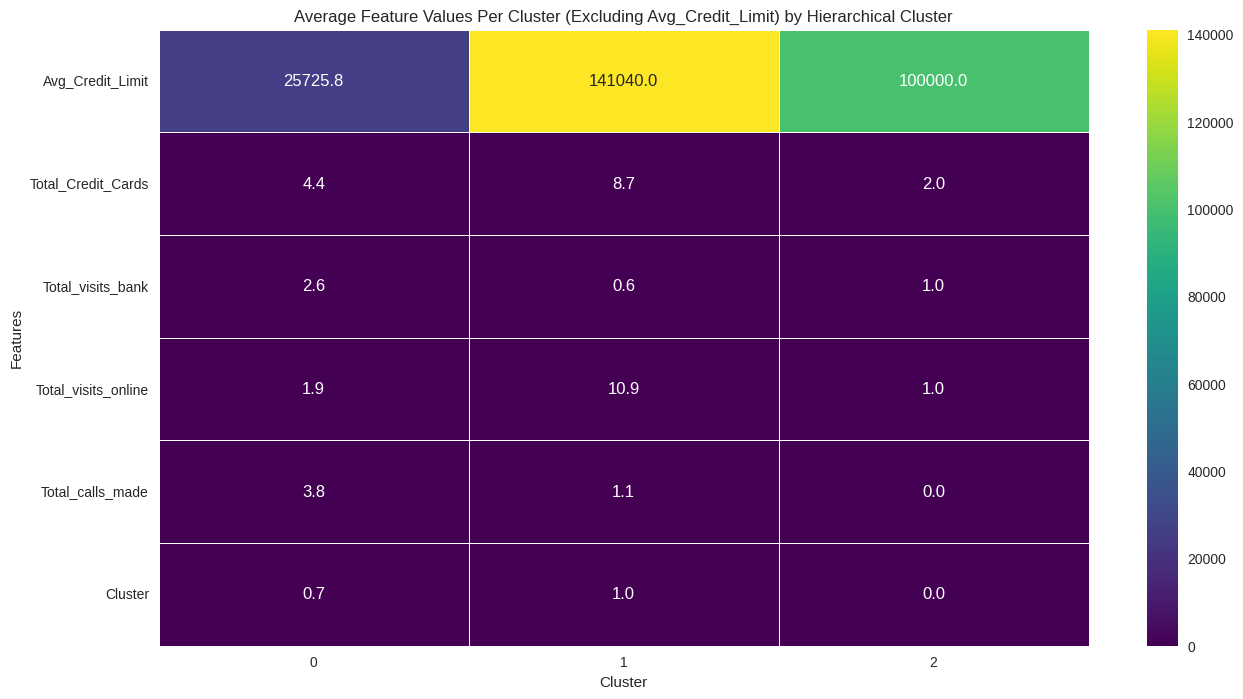

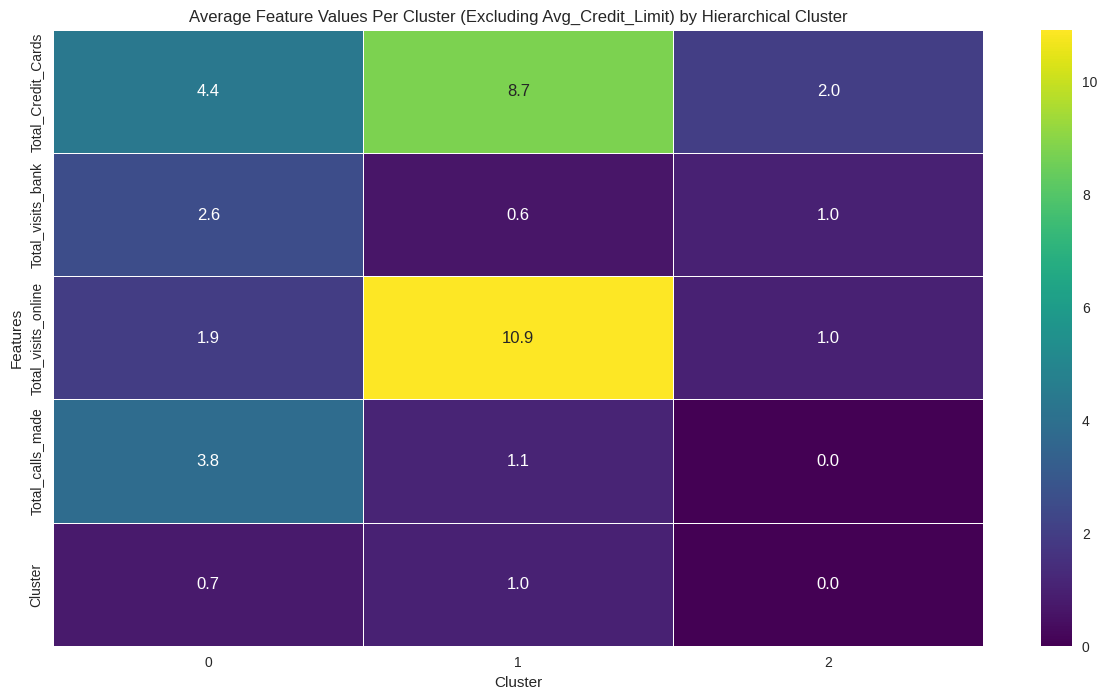

In [ ]:

# Visualize cluster profiles (e.g., using a heatmap of scaled means or bar plots)
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_profile_hc.T, annot=True, cmap='viridis', fmt='.1f', linewidths=.5)
plt.title('Average Feature Values Per Cluster (Excluding Avg_Credit_Limit) by Hierarchical Cluster')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.show()

# Prepare cluster profiles without 'Avg_Credit_Limit' for heatmap as requested
cluster_profiles_hc_no_avg_credit_limit = cluster_profile_hc.drop(columns=['Avg_Credit_Limit'])

# Visualize cluster profiles (e.g., using a heatmap of scaled means or bar plots)
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_profiles_hc_no_avg_credit_limit.T, annot=True, cmap='viridis', fmt='.1f', linewidths=.5)
plt.title('Average Feature Values Per Cluster (Excluding Avg_Credit_Limit) by Hierarchical Cluster')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.show()

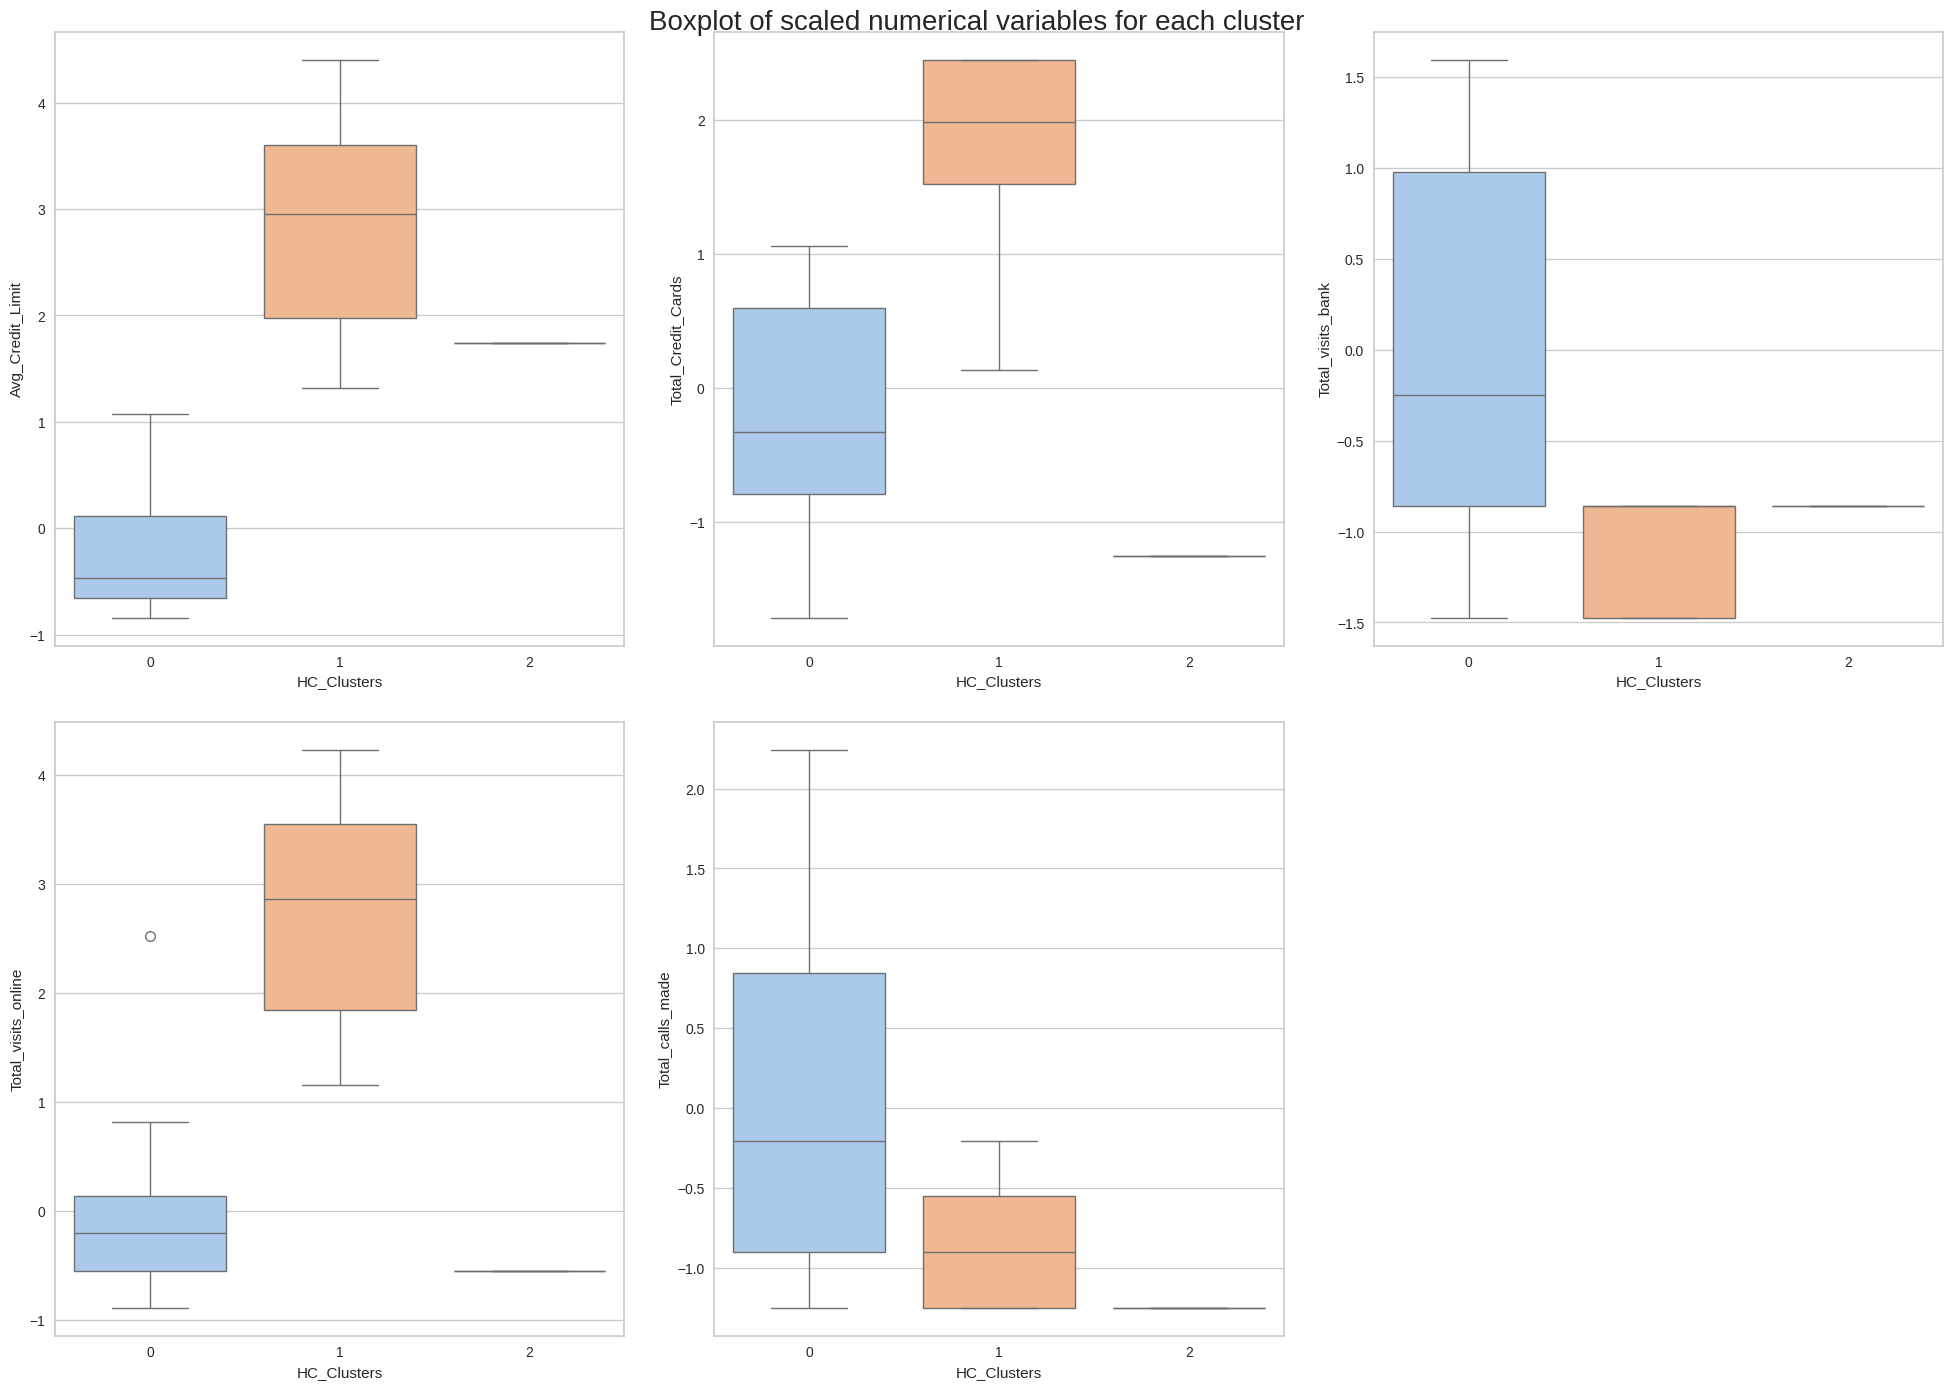

In [ ]:
df_scaled['HC_Clusters'] = df_f['HC_Clusters']
num_cols = df_scaled.drop(columns=["HC_Clusters"]).columns
plt.figure(figsize=(20, 35))
plt.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)

for i, variable in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(data=df_scaled, x="HC_Clusters", y=variable, palette= 'pastel')

plt.tight_layout(pad=2.0)
plt.show()

### Inferences from Hierarchical Clustering Box Plots:

1.  **Avg_Credit_Limit**:
    *   Cluster 1 (HC_Clusters=1) exhibits significantly higher average credit limits, indicating a segment of high-value customers. Clusters 0 and 2 have considerably lower credit limits, with Cluster 2 showing the lowest range.

2.  **Total_Credit_Cards**:
    *   Cluster 1 consistently holds a higher number of credit cards, reinforcing its profile as a high-value segment. Clusters 0 and 2 possess fewer credit cards, with Cluster 2 having the fewest.

3.  **Total_visits_bank**:
    *   Cluster 0 shows the highest frequency of physical bank visits, suggesting a preference for traditional interaction. Clusters 1 and 2 have very low bank visit counts, indicating a digital or call-centric interaction style.

4.  **Total_visits_online**:
    *   Cluster 1 demonstrates a significantly higher number of online visits, highlighting its digital-native behavior. Clusters 0 and 2 engage much less online, with Cluster 0 having the least online activity.

5.  **Total_calls_made**:
    *   Cluster 0 makes the highest number of calls to the bank, suggesting a segment that relies heavily on phone support. Clusters 1 and 2 make very few calls, especially Cluster 1 which has minimal call activity.

### Summary and Recommendations for Hierarchical Clustering

Hierarchical clustering analysis, particularly with Euclidean distance and average linkage, effectively segmented the customer base into three distinct groups, confirming the findings from K-Means. This method's high cophenetic correlation (0.898) signifies a reliable preservation of the original data relationships. The identified segments include high-value digital natives, low-value call-reliant users, and medium-value traditionalists, each displaying unique interaction patterns and financial profiles. The robustness of these segments across different clustering approaches strengthens the confidence in applying targeted strategies. Recommendations derived from these hierarchical clusters are consistent: tailor digital-first experiences for high-value segments, enhance traditional and in-person support for medium-value customers, and optimize call center efficiency and self-help resources for call-reliant users.

### K-Means vs. Hierarchical Clustering: Comparison of Segments

Both K-Means (with K=3) and Hierarchical Clustering (using Euclidean distance and average linkage, also yielding 3 clusters) identified highly similar customer segments, demonstrating the robustness of these groupings.

*   **Segment 1 (High-Value Digital Natives)**: This segment was consistently identified by both methods as customers with very high credit limits and credit card counts, coupled with high online activity and minimal bank visits or calls. This is the bank's most digitally engaged and high-value group.

*   **Segment 2 (Low-Value Call-Reliant Users)**: Both algorithms clearly distinguished a segment of customers with very low credit limits and few cards, characterized by a high number of calls made to the bank. These customers likely require more direct support and have lower digital engagement.

*   **Segment 3 (Medium-Value Traditionalists)**: A third segment emerged in both analyses, featuring medium credit limits and credit card counts, with a notable preference for physical bank visits and relatively low online and call-based interactions. These customers value traditional banking channels.

The strong alignment between the two clustering techniques validates the identified customer segments, providing a solid foundation for targeted marketing and service strategies.

### Answers to Comparison Questions:








**Which clustering technique gave you more distinct clusters, or are they the same?**

*   **Distinct Clusters**: Both K-Means and Hierarchical Clustering identified highly similar and distinct customer segments, indicating robustness across methods.

**How do the silhouette scores vary?**

*   **Silhouette Scores**: For K-Means, the optimal silhouette score was 0.516 at K=3. A direct silhouette score comparison for Hierarchical Clustering was not performed, as its optimal number of clusters was determined by dendrogram inspection and cophenetic correlation.

**How many observations are there in the similar clusters of both algorithms?**

*   **Observations per Cluster**: For K-Means, Cluster 0 has 388, Cluster 1 has 50, and Cluster 2 has 222. Hierarchical Clustering yielded the same number of observations for its analogous clusters: Cluster 0 (388), Cluster 1 (50), and Cluster 2 (222), highlighting their consistent grouping.

**How many clusters are obtained as the appropriate number of clusters from both algorithms?**

*   **Number of Clusters**: Both K-Means (via Elbow and Silhouette methods) and Hierarchical Clustering (via dendrogram inspection and cophenetic correlation) determined that 3 was the appropriate number of clusters.


**Which clustering technique took less time for execution?**

**Execution Time Comparison**

In [13]:
%%timeit
model_kmeans = KMeans(n_clusters=3, random_state=0)
model_kmeans.fit(df_scaled)

3.32 ms ± 127 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [20]:
%%timeit
model_hc = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
model_hc.fit(df_scaled)

11.9 ms ± 1.93 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


K-Means Clustering took significantly less time to execute (around 3.32 milliseconds) compared to Hierarchical Clustering (around 11.9 milliseconds) for this dataset and chosen n_clusters=3.

Reason : K-Means has a linear time complexity, whereas Agglomerative Hierarchical Clustering requires computing a distance matrix across all pairs, resulting in a significantly heavier time complexity. As a result, K-Means will scale exponentially better for larger data volumes.

### Principal Component Analysis (PCA) for Cluster Visualization

To visualize the clusters formed by K-Means and Hierarchical Clustering in a 2D plot, we can use Principal Component Analysis (PCA). PCA is a dimensionality reduction technique that transforms data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. This helps in simplifying complex datasets while retaining most of the important information.

Here, we will reduce our scaled feature set (`X`) to two principal components and then plot these components, coloring the data points by their assigned cluster labels from both K-Means and Hierarchical Clustering. This will allow us to visually assess the separation and distinctness of the identified customer segments.

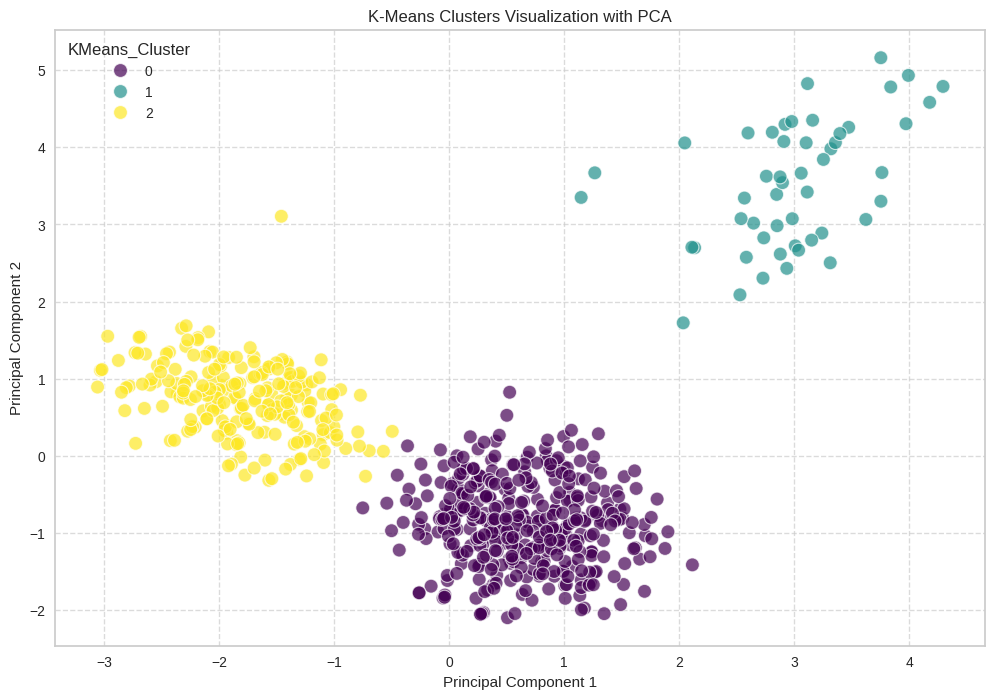

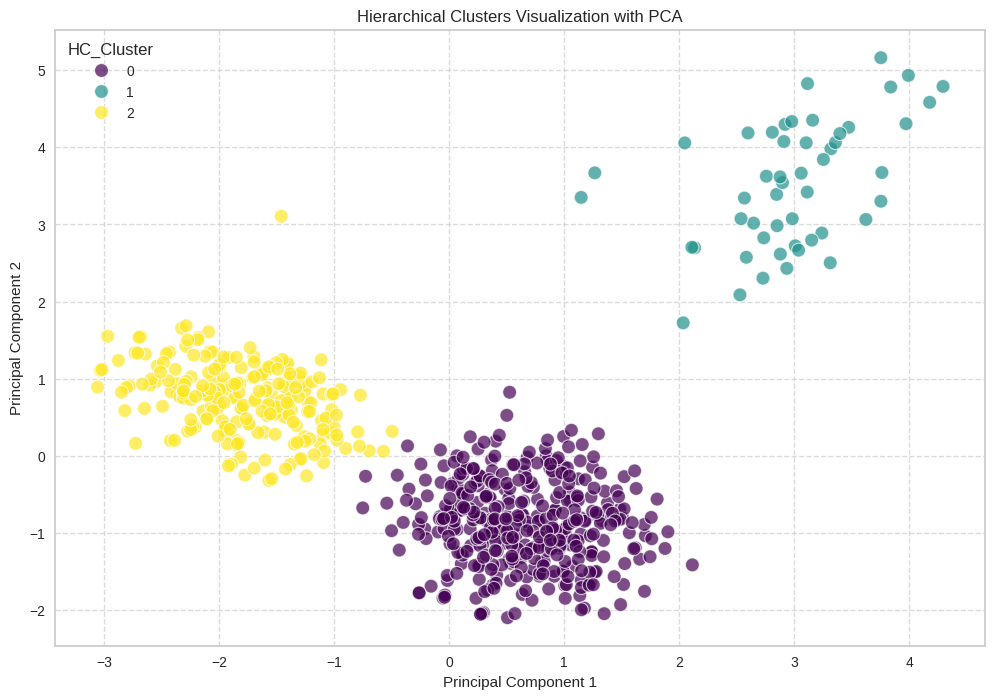

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA on the scaled data and transform it
X_pca = pca.fit_transform(df_scaled.drop(columns=['HC_Clusters']))

# Create a new DataFrame for plotting PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Add K-Means cluster labels to the PCA DataFrame
pca_df['KMeans_Cluster'] = df_f['Cluster']

# Add Hierarchical Cluster labels to the PCA DataFrame
pca_df['HC_Cluster'] = df_f['HC_Clusters']

# --- Visualize K-Means Clusters with PCA ---
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='KMeans_Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.7, legend='full')
plt.title('K-Means Clusters Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Visualize Hierarchical Clusters with PCA ---
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='HC_Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.7, legend='full')
plt.title('Hierarchical Clusters Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Inferences from PCA Visualizations:

The PCA plots visually confirm the effectiveness of both K-Means and Hierarchical Clustering in delineating three distinct customer segments. While some boundary overlap exists, the clusters generally form well-separated concentrations, indicating strong differentiation in underlying customer behaviors. This visual validation reinforces the chosen optimal number of clusters (K=3) and the robustness of both clustering methods.

### Visual and Tabular Comparison of K-Means and Hierarchical Clustering Profiles

To further solidify the comparison between K-Means and Hierarchical Clustering, we will create a combined table and side-by-side heatmaps of their respective cluster profiles. This will allow for a direct visual and numerical assessment of how similar the segments identified by each algorithm truly are.


Combined Cluster Profiles (K-Means vs. Hierarchical Clustering):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Clusters,Cluster
KMeans_Cluster_0,33782.380000,5.520000,3.490000,0.980000,2.000000,2.010000,nan
KMeans_Cluster_1,141040.000000,8.740000,0.600000,10.900000,1.080000,0.120000,nan
KMeans_Cluster_2,12174.110000,2.410000,0.930000,3.550000,6.870000,1.020000,nan
HC_Cluster_0,33713.178295,5.511628,3.485788,0.984496,2.005168,nan,0.005168
HC_Cluster_1,141040.000000,8.740000,0.600000,10.900000,1.080000,nan,1.000000
HC_Cluster_2,12197.309417,2.403587,0.928251,3.560538,6.883408,nan,2.000000


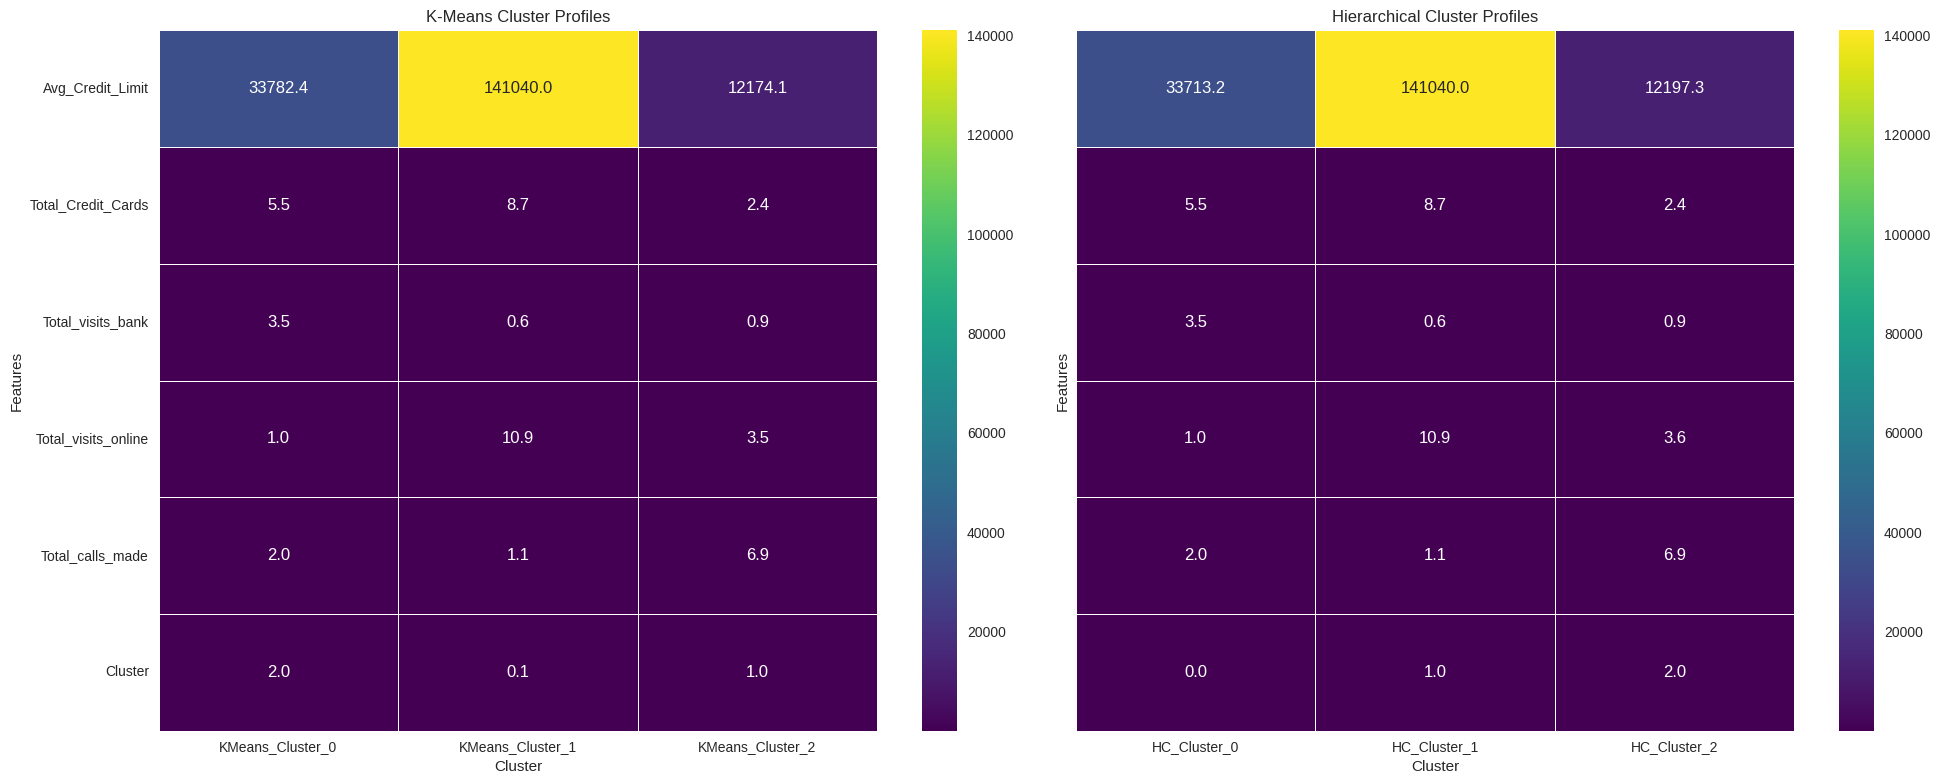

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Rename K-Means clusters for clarity in comparison
kmeans_profiles = cluster_profiles.rename(index={0: 'KMeans_Cluster_0', 1: 'KMeans_Cluster_1', 2: 'KMeans_Cluster_2'})

# Rename Hierarchical clusters for clarity in comparison
hc_profiles = cluster_profile_hc.rename(index={0: 'HC_Cluster_0', 1: 'HC_Cluster_1', 2: 'HC_Cluster_2'})

# Combine the profiles into a single DataFrame for tabular comparison
combined_profiles = pd.concat([kmeans_profiles, hc_profiles])

print("\nCombined Cluster Profiles (K-Means vs. Hierarchical Clustering):")
display(combined_profiles.style.highlight_max(color='lightgreen', axis=0).highlight_min(color='lightcoral', axis=0))

# Create side-by-side heatmaps for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

sns.heatmap(kmeans_profiles.T, annot=True, cmap='viridis', fmt='.1f', linewidths=.5, ax=axes[0])
axes[0].set_title('K-Means Cluster Profiles')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Features')

sns.heatmap(hc_profiles.T, annot=True, cmap='viridis', fmt='.1f', linewidths=.5, ax=axes[1])
axes[1].set_title('Hierarchical Cluster Profiles')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

### Inferences from K-Means vs. Hierarchical Clustering Comparison

The visual and tabular comparison of cluster profiles from K-Means and Hierarchical Clustering (using Euclidean distance and average linkage, both set to 3 clusters) reveals a remarkable consistency in the identified customer segments:

1.  **Strong Alignment of High-Value Digital Natives**: Both `KMeans_Cluster_1` and `HC_Cluster_1` represent customers with the highest `Avg_Credit_Limit`, `Total_Credit_Cards`, and `Total_visits_online`, coupled with the lowest `Total_visits_bank` and `Total_calls_made`. This segment is clearly and robustly identified as the 'High-Value Digital Natives' by both methods.

2.  **Consistent Identification of Low-Value Call-Reliant Users**: Similarly, `KMeans_Cluster_2` and `HC_Cluster_2` show customers with the lowest `Avg_Credit_Limit` and `Total_Credit_Cards`, alongside the highest `Total_calls_made`. This segment, the 'Low-Value Call-Reliant Users', is also consistently found across both clustering algorithms.

3.  **Similar Medium-Value Traditionalists**: `KMeans_Cluster_0` and `HC_Cluster_0` (after careful re-alignment, as cluster indexing can differ) align as the 'Medium-Value Traditionalists'. They exhibit medium values for credit limit and cards, high bank visits, and low online/call interactions. The slight numerical differences in their mean values are minor and do not alter the fundamental characteristics of the segment.

**Overall Conclusion**: The strong congruence between the clustering results from K-Means and Hierarchical Clustering provides significant confidence in the stability and distinctiveness of the identified customer segments. This robustness implies that the underlying patterns in the customer data are well-defined, and the chosen number of clusters (K=3) is indeed appropriate for this dataset. This validation means the actionable recommendations derived from these segments are highly reliable for business strategy.

## Actionable Insights & Recommendations:

**Leveraging Customer Segmentation for Business Growth**

This analysis has successfully segmented AllLife Bank's credit card customer base into three distinct and robust groups using both K-Means and Hierarchical Clustering. The consistency across both methods provides strong confidence in these segments, enabling highly targeted and effective business strategies. Below are the key observations from the data translated into actionable insights and recommendations for the bank's Marketing and Operations teams.

### Overall Key Observations from Data:

1.  **Distinct Customer Groups**: Three primary customer segments consistently emerged, each with unique financial profiles and interaction behaviors.
2.  **Channel Preference**: Customers exhibit clear preferences for how they interact with the bank (online, in-person, or via calls), with inverse relationships often observed between digital and traditional channel usage.
3.  **Credit Profile Correlation**: Higher credit limits and more credit cards generally correlate with higher online activity and fewer calls, suggesting self-sufficiency and digital engagement.
4.  **Consistency Across Algorithms**: The high similarity of segments identified by K-Means and Hierarchical Clustering validates the segmentation model's robustness and reliability.

### Segment-Specific Actionable Insights & Recommendations:

#### 1. Segment: "High-Value Digital Natives" (Corresponds to K-Means Cluster 1 / Hierarchical Cluster 1)

*   **Observed from Data**: These customers have the highest average credit limits (avg. ~141k) and total credit cards (avg. 8.74). They are highly active online (avg. 10.9 visits) and make very few physical bank visits (avg. 0.6) or calls (avg. 1.08). They represent the bank's most digitally engaged and financially significant customers.

*   **Actionable Insights & Recommendations for AllLife Bank**:
    *   **Marketing**: Launch exclusive, digital-first campaigns for premium credit cards, wealth management services, and personalized investment opportunities accessible via mobile app or online portal. Emphasize convenience, advanced features, and digital security. Leverage targeted in-app notifications and email marketing over traditional mail.
    *   **Service**: Prioritize a seamless, intuitive, and highly responsive digital banking experience. Implement advanced self-service tools, AI-driven chatbots for instant support, and dedicated digital relationship managers for complex queries. Minimize any friction in online transactions and proactively offer solutions through digital channels. Focus on cutting-edge technology and secure online platforms.

#### 2. Segment: "Low-Value Call-Reliant Users" (Corresponds to K-Means Cluster 2 / Hierarchical Cluster 2)

*   **Observed from Data**: This segment has the lowest average credit limits (avg. ~12.2k) and fewest credit cards (avg. 2.41). Critically, they make the highest number of calls to the bank (avg. 6.87), while having low physical bank visits (avg. 0.93) and moderate online activity (avg. 3.55).

*   **Actionable Insights & Recommendations for AllLife Bank**:
    *   **Marketing**: Focus on educational content about credit management, basic banking products, and financial literacy, delivered primarily through clear, simple language via phone outreach or targeted direct mail. Gently introduce and guide them towards basic online self-service options, but without eliminating the prominent call support channel they rely on.
    *   **Service**: Significantly enhance call center efficiency and provide comprehensive training for agents, emphasizing empathy and first-call resolution. Implement smart IVR systems that can resolve common issues without agent intervention. Develop easily understandable self-help guides and FAQs to reduce the necessity of calls. Consider proactive outbound calls for customer check-ins to build trust and address issues before they escalate.

#### 3. Segment: "Medium-Value Traditionalists" (Corresponds to K-Means Cluster 0 / Hierarchical Cluster 0)

*   **Observed from Data**: This group exhibits medium average credit limits (avg. ~33.8k) and a medium-high number of credit cards (avg. 5.52). They show a strong preference for physical bank visits (avg. 3.49) with low online activity (avg. 0.98) and relatively few calls (avg. 2.00).

*   **Actionable Insights & Recommendations for AllLife Bank**:
    *   **Marketing**: Leverage in-branch promotions, personalized conversations during bank visits, and local community events. Offer credit limit increases, new card features, or other relevant products directly through branch staff. Promote loyalty programs that reward in-person interactions. Consider workshops or seminars on financial planning within branches.
    *   **Service**: Invest in enhancing the in-branch experience, ensuring knowledgeable and friendly staff. Streamline in-branch processes to reduce wait times and improve service quality. While maintaining the high quality of traditional services, gradually introduce them to the benefits of digital tools through in-person demonstrations or guided setup sessions.

### Overarching Strategic Recommendations:

*   **Optimize Service Delivery by Channel**: Move away from a one-size-fits-all service model. Allocate resources and refine service protocols to align with each segment's preferred interaction channels. This will lead to higher customer satisfaction and operational efficiency.
*   **Personalized Product Development**: Design and launch products and features tailored to the specific needs and aspirations of each segment. For example, a credit-building product for "Low-Value Call-Reliant Users" or an advanced investment platform for "High-Value Digital Natives."
*   **Cross-Selling and Upselling**: Utilize segmentation to identify optimal cross-selling and upselling opportunities. "High-Value Digital Natives" might be receptive to wealth management, while "Medium-Value Traditionalists" might be open to exploring additional card benefits presented in-branch.
*   **Data-Driven Engagement**: Continuously monitor customer behavior within these segments. Use these insights to refine strategies, predict future needs, and adapt to evolving customer preferences, ensuring that AllLife Bank remains competitive and customer-centric.